# Impact of Adversarial Attacks on Spiking Neural Networks
## Rate Coding vs Temporal Coding — Comparative Robustness Study

**Research Question:** Does spike encoding strategy affect adversarial robustness in SNNs?

| Model | Dataset | Encoding / Type |
|-------|---------|------------------|
| SNN-Rate | MNIST / CIFAR-10 | Rate coding (Bernoulli) |
| SNN-Temporal | MNIST / CIFAR-10 | Latency coding (first-spike) |
| ANN (MLP) | MNIST | Standard baseline |
| CNN (VGG-style) | CIFAR-10 | Standard baseline |

**Attacks evaluated:** FGSM · PGD  
**Method:** Surrogate gradient learning (Neftci et al., 2019)


## 0 · Setup & Imports

In [1]:
# ── Install ────────────────────────────────────────────────────────────────────
!pip install snntorch seaborn scikit-learn --quiet

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision, torchvision.transforms as transforms
import snntorch as snn
from snntorch import surrogate
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import time, warnings, os
warnings.filterwarnings('ignore')

# ── Aesthetic theme ────────────────────────────────────────────────────────────
PALETTE = {
    'snn_rate'     : '#5B8DB8',   # steel blue
    'snn_temporal' : '#E8834A',   # warm orange
    'ann'          : '#6BAE75',   # sage green
    'cnn'          : '#B36BAE',   # mauve
    'fgsm'         : '#E8834A',
    'pgd'          : '#C0392B',
    'clean'        : '#2ECC71',
    'bg'           : '#F7F9FC',
    'grid'         : '#DDE3EC',
}

plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : PALETTE['bg'],
    'axes.grid'         : True,
    'grid.color'        : PALETTE['grid'],
    'grid.linewidth'    : 0.6,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : False,
    'axes.spines.bottom': False,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 9,
    'legend.framealpha' : 0.85,
    'figure.dpi'        : 120,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('figures', exist_ok=True)
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}  |  snnTorch: {snn.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 3.2 MB/s eta 0:00:0000:01
Device : cuda
PyTorch: 2.10.0+cu128  |  snnTorch: 0.9.4


## 1 · Encoding Strategies

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# ENCODING FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def rate_encode(x, num_steps):
    """
    Rate coding (Neftci et al. 2019):
      pixel ∈ [0,1] → Bernoulli spike probability each timestep.
      Bright pixels fire frequently; dark pixels rarely.
    """
    x_exp = x.unsqueeze(0).expand(num_steps, *x.shape)
    return torch.bernoulli(x_exp)


def temporal_encode(x, num_steps):
    """
    Latency / first-spike temporal coding:
      Bright pixel → fires at early timestep (low latency).
      Dark pixel   → fires at late timestep  (high latency).
      spike_time = round((1 - pixel) * (T-1))
      Only one spike per neuron per sample (sparse representation).
    """
    T = num_steps
    spikes = torch.zeros(T, *x.shape, device=x.device)
    spike_times = ((1.0 - x.clamp(0, 1)) * (T - 1)).round().long().clamp(0, T - 1)
    for t in range(T):
        spikes[t] = (spike_times == t).float()
    return spikes


print('Encoders defined.')

Encoders defined.


### Figure 1 — Encoding strategy visualisation

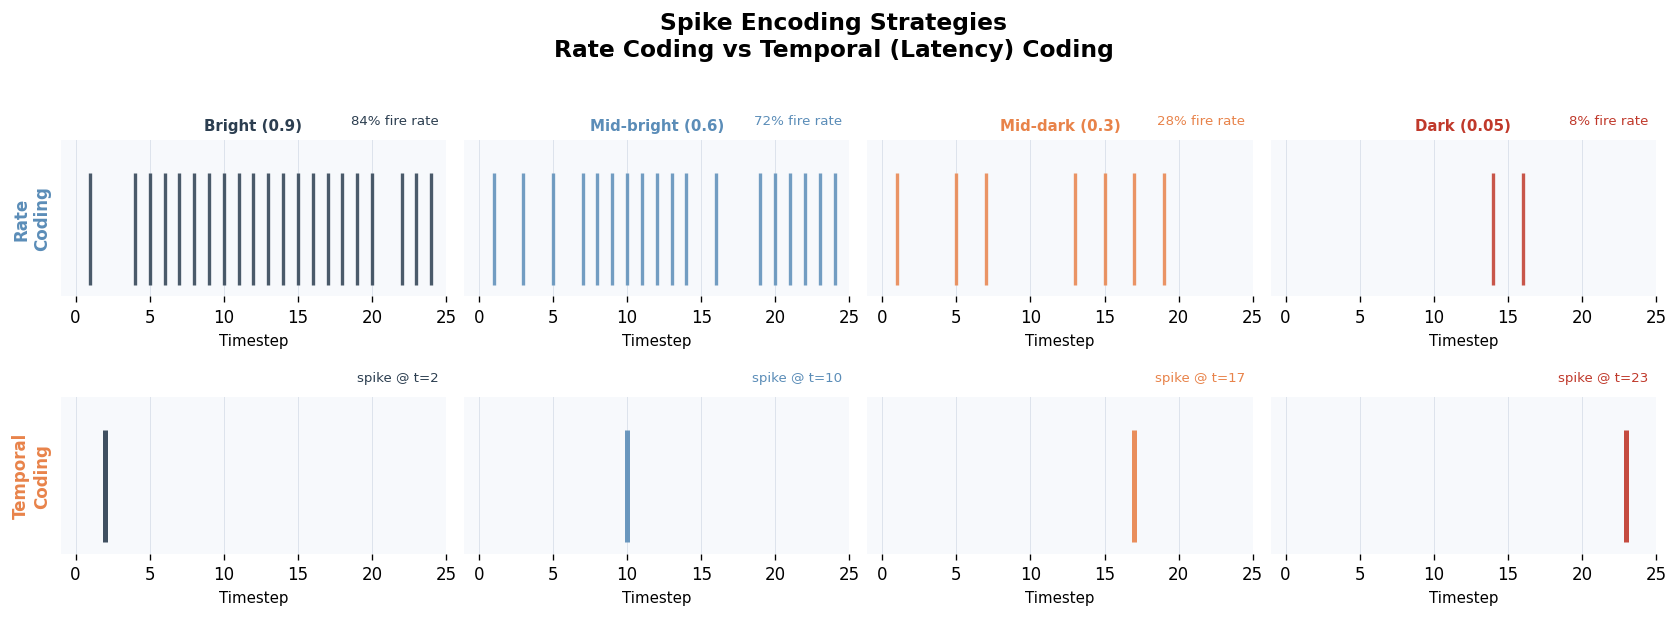

Fig 1 saved.


In [3]:
# ── Figure 1: Side-by-side encoding comparison ────────────────────────────────
T = 25
test_pixels = np.array([0.9, 0.6, 0.3, 0.05])   # bright → dark
labels_px   = ['Bright (0.9)', 'Mid-bright (0.6)', 'Mid-dark (0.3)', 'Dark (0.05)']
colors_px   = ['#2c3e50', '#5B8DB8', '#E8834A', '#C0392B']

np.random.seed(42)
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
fig.suptitle('Spike Encoding Strategies\nRate Coding vs Temporal (Latency) Coding',
             fontsize=14, fontweight='bold', y=1.02)

for col, (pv, lab, col_c) in enumerate(zip(test_pixels, labels_px, colors_px)):
    px = torch.tensor([pv])

    # Rate spikes
    rate_spikes = torch.bernoulli(px.expand(T)).numpy()
    ax_r = axes[0, col]
    spike_t = np.where(rate_spikes)[0]
    ax_r.vlines(spike_t, 0, 1, colors=col_c, linewidth=2, alpha=0.85)
    ax_r.set_xlim(-1, T)
    ax_r.set_ylim(-0.1, 1.3)
    ax_r.set_yticks([])
    ax_r.set_xlabel('Timestep', fontsize=9)
    ax_r.set_title(lab, fontsize=9, fontweight='bold', color=col_c)
    fire_rate = spike_t.size / T
    ax_r.text(0.98, 1.1, f'{fire_rate:.0%} fire rate',
              transform=ax_r.transAxes, ha='right', fontsize=8, color=col_c)
    if col == 0:
        ax_r.set_ylabel('Rate\nCoding', fontsize=10, fontweight='bold', rotation=90,
                        labelpad=6, color=PALETTE['snn_rate'])

    # Temporal spikes
    t_spike = int(round((1 - pv) * (T - 1)))
    ax_t = axes[1, col]
    ax_t.vlines([t_spike], 0, 1, colors=col_c, linewidth=3, alpha=0.9)
    ax_t.set_xlim(-1, T)
    ax_t.set_ylim(-0.1, 1.3)
    ax_t.set_yticks([])
    ax_t.set_xlabel('Timestep', fontsize=9)
    ax_t.text(0.98, 1.1, f'spike @ t={t_spike}',
              transform=ax_t.transAxes, ha='right', fontsize=8, color=col_c)
    if col == 0:
        ax_t.set_ylabel('Temporal\nCoding', fontsize=10, fontweight='bold', rotation=90,
                        labelpad=6, color=PALETTE['snn_temporal'])

plt.tight_layout()
plt.savefig('figures/fig01_encoding_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 1 saved.')

## 2 · MNIST — Architectures

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# MNIST — HYPERPARAMETERS & DATA
# ══════════════════════════════════════════════════════════════════════════════
M_CFG = {
    'num_steps'  : 25,
    'beta'       : 0.90,
    'batch_size' : 256,
    'lr'         : 2e-3,
    'num_epochs' : 20,
    'hidden'     : 1000,
}

tf_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.clamp(0, 1)),
])
mnist_train = torchvision.datasets.MNIST('./data', train=True,  download=True, transform=tf_mnist)
mnist_test  = torchvision.datasets.MNIST('./data', train=False, download=True, transform=tf_mnist)
train_ldr_m = DataLoader(mnist_train, batch_size=M_CFG['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
test_ldr_m  = DataLoader(mnist_test,  batch_size=M_CFG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
print(f'MNIST  train={len(mnist_train):,}  test={len(mnist_test):,}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.09MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.52MB/s]

MNIST  train=60,000  test=10,000


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# MNIST ARCHITECTURES
# SNN (Rate & Temporal share the same net — only encoder differs)
#   Input(784) → FC(1000) → LIF → FC(10) → LIF
# ANN
#   Input(784) → FC(1000) → ReLU → FC(10)
# ══════════════════════════════════════════════════════════════════════════════

class SNN_MNIST(nn.Module):
    def __init__(self, hidden=1000, beta=0.9, num_steps=25):
        super().__init__()
        self.num_steps = num_steps
        sg = surrogate.fast_sigmoid(slope=25)
        self.fc1  = nn.Linear(784, hidden)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=sg)
        self.fc2  = nn.Linear(hidden, 10)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=sg)

    def forward(self, spike_data):
        # spike_data: (T, B, 1, 28, 28)
        T = spike_data.shape[0]
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec = []
        for t in range(T):
            x = spike_data[t].view(spike_data[t].size(0), -1)
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
        return torch.stack(spk2_rec, dim=0).sum(0)  # spike count decoding


class ANN_MNIST(nn.Module):
    def __init__(self, hidden=1000):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden)
        self.fc2 = nn.Linear(hidden, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc2(F.relu(self.fc1(x)))


print('MNIST architectures defined.')

MNIST architectures defined.


## 3 · MNIST — Training

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAINING HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def train_snn_epoch(model, loader, optimizer, criterion, encode_fn, num_steps, device):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        spikes = encode_fn(imgs, num_steps).to(device)
        optimizer.zero_grad()
        out = model(spikes)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, 100. * correct / total


def eval_snn(model, loader, encode_fn, num_steps, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            spikes = encode_fn(imgs, num_steps).to(device)
            out = model(spikes)
            correct += (out.argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return 100. * correct / total


def train_ann_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, 100. * correct / total


def eval_ann(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (model(imgs).argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return 100. * correct / total


print('Training helpers defined.')

Training helpers defined.


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAIN: SNN-Rate (MNIST)  — 1 seed run for poster results
# Change NUM_RUNS to 5 for paper with confidence intervals
# ══════════════════════════════════════════════════════════════════════════════
NUM_RUNS = 5  # set to 5 for full paper run
NUM_EPOCHS_M = M_CFG['num_epochs']

snn_rate_curves, snn_rate_accs = [], []

for run in range(NUM_RUNS):
    seed = 42 + run * 7
    torch.manual_seed(seed); np.random.seed(seed)
    model_sr = SNN_MNIST(hidden=M_CFG['hidden'], beta=M_CFG['beta'], num_steps=M_CFG['num_steps']).to(device)
    opt   = torch.optim.Adam(model_sr.parameters(), lr=M_CFG['lr'], betas=(0.9, 0.999))
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS_M)
    crit  = nn.CrossEntropyLoss()
    curve = []
    t0 = time.time()
    for ep in range(1, NUM_EPOCHS_M + 1):
        _, tr_acc = train_snn_epoch(model_sr, train_ldr_m, opt, crit, rate_encode, M_CFG['num_steps'], device)
        sched.step()
        curve.append(tr_acc)
        if ep % 5 == 0 or ep == NUM_EPOCHS_M:
            te_acc = eval_snn(model_sr, test_ldr_m, rate_encode, M_CFG['num_steps'], device)
            print(f'[SNN-Rate | run {run+1} | ep {ep:2d}] train={tr_acc:.1f}%  test={te_acc:.1f}%  ({time.time()-t0:.0f}s)')
    final_acc = eval_snn(model_sr, test_ldr_m, rate_encode, M_CFG['num_steps'], device)
    snn_rate_accs.append(final_acc)
    snn_rate_curves.append(curve)
    print(f'  → Run {run+1} final test accuracy: {final_acc:.2f}%')

# Save best weights
torch.save(model_sr.state_dict(), 'snn_rate_mnist.pt')
print(f'\nSNN-Rate MNIST  mean={np.mean(snn_rate_accs):.2f}%  std={np.std(snn_rate_accs):.2f}%')

[SNN-Rate | run 1 | ep  5] train=95.6%  test=95.8%  (66s)
[SNN-Rate | run 1 | ep 10] train=97.8%  test=97.3%  (133s)
[SNN-Rate | run 1 | ep 15] train=99.3%  test=97.8%  (199s)
[SNN-Rate | run 1 | ep 20] train=99.6%  test=97.9%  (265s)
  → Run 1 final test accuracy: 98.03%
[SNN-Rate | run 2 | ep  5] train=95.6%  test=96.2%  (65s)
[SNN-Rate | run 2 | ep 10] train=97.8%  test=96.4%  (130s)
[SNN-Rate | run 2 | ep 15] train=99.4%  test=97.6%  (194s)
[SNN-Rate | run 2 | ep 20] train=99.6%  test=97.8%  (258s)
  → Run 2 final test accuracy: 97.78%
[SNN-Rate | run 3 | ep  5] train=96.0%  test=95.2%  (64s)
[SNN-Rate | run 3 | ep 10] train=98.1%  test=97.0%  (128s)
[SNN-Rate | run 3 | ep 15] train=99.5%  test=98.0%  (195s)
[SNN-Rate | run 3 | ep 20] train=99.6%  test=98.1%  (260s)
  → Run 3 final test accuracy: 98.11%
[SNN-Rate | run 4 | ep  5] train=96.8%  test=95.8%  (66s)
[SNN-Rate | run 4 | ep 10] train=98.6%  test=97.2%  (132s)
[SNN-Rate | run 4 | ep 15] train=99.7%  test=98.1%  (199s)
[SNN-

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAIN: SNN-Temporal (MNIST)
# Same architecture, same hyperparams — only encoder changes
# ══════════════════════════════════════════════════════════════════════════════
snn_temp_curves, snn_temp_accs = [], []

for run in range(NUM_RUNS):
    seed = 42 + run * 7
    torch.manual_seed(seed); np.random.seed(seed)
    model_st = SNN_MNIST(hidden=M_CFG['hidden'], beta=M_CFG['beta'], num_steps=M_CFG['num_steps']).to(device)
    opt   = torch.optim.Adam(model_st.parameters(), lr=M_CFG['lr'], betas=(0.9, 0.999))
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS_M)
    crit  = nn.CrossEntropyLoss()
    curve = []
    t0 = time.time()
    for ep in range(1, NUM_EPOCHS_M + 1):
        _, tr_acc = train_snn_epoch(model_st, train_ldr_m, opt, crit, temporal_encode, M_CFG['num_steps'], device)
        sched.step()
        curve.append(tr_acc)
        if ep % 5 == 0 or ep == NUM_EPOCHS_M:
            te_acc = eval_snn(model_st, test_ldr_m, temporal_encode, M_CFG['num_steps'], device)
            print(f'[SNN-Temp | run {run+1} | ep {ep:2d}] train={tr_acc:.1f}%  test={te_acc:.1f}%  ({time.time()-t0:.0f}s)')
    final_acc = eval_snn(model_st, test_ldr_m, temporal_encode, M_CFG['num_steps'], device)
    snn_temp_accs.append(final_acc)
    snn_temp_curves.append(curve)
    print(f'  → Run {run+1} final test accuracy: {final_acc:.2f}%')

torch.save(model_st.state_dict(), 'snn_temporal_mnist.pt')
print(f'\nSNN-Temporal MNIST  mean={np.mean(snn_temp_accs):.2f}%  std={np.std(snn_temp_accs):.2f}%')

[SNN-Temp | run 1 | ep  5] train=97.5%  test=97.2%  (67s)
[SNN-Temp | run 1 | ep 10] train=98.9%  test=97.5%  (135s)
[SNN-Temp | run 1 | ep 15] train=99.7%  test=98.1%  (201s)
[SNN-Temp | run 1 | ep 20] train=99.9%  test=98.0%  (268s)
  → Run 1 final test accuracy: 98.02%
[SNN-Temp | run 2 | ep  5] train=97.5%  test=96.8%  (67s)
[SNN-Temp | run 2 | ep 10] train=99.0%  test=97.9%  (134s)
[SNN-Temp | run 2 | ep 15] train=99.8%  test=97.8%  (199s)
[SNN-Temp | run 2 | ep 20] train=99.9%  test=97.9%  (265s)
  → Run 2 final test accuracy: 97.94%
[SNN-Temp | run 3 | ep  5] train=97.4%  test=96.1%  (66s)
[SNN-Temp | run 3 | ep 10] train=98.9%  test=97.6%  (133s)
[SNN-Temp | run 3 | ep 15] train=99.7%  test=97.9%  (196s)
[SNN-Temp | run 3 | ep 20] train=99.9%  test=98.0%  (261s)
  → Run 3 final test accuracy: 97.96%
[SNN-Temp | run 4 | ep  5] train=97.4%  test=96.2%  (66s)
[SNN-Temp | run 4 | ep 10] train=99.0%  test=97.7%  (132s)
[SNN-Temp | run 4 | ep 15] train=99.8%  test=98.0%  (199s)
[SNN-

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAIN: ANN (MNIST baseline)
# ══════════════════════════════════════════════════════════════════════════════
ann_curves, ann_accs = [], []

for run in range(NUM_RUNS):
    seed = 42 + run * 7
    torch.manual_seed(seed); np.random.seed(seed)
    model_ann = ANN_MNIST(hidden=M_CFG['hidden']).to(device)
    opt   = torch.optim.Adam(model_ann.parameters(), lr=M_CFG['lr'], betas=(0.9, 0.999))
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS_M)
    crit  = nn.CrossEntropyLoss()
    curve = []
    t0 = time.time()
    for ep in range(1, NUM_EPOCHS_M + 1):
        _, tr_acc = train_ann_epoch(model_ann, train_ldr_m, opt, crit, device)
        sched.step()
        curve.append(tr_acc)
        if ep % 5 == 0 or ep == NUM_EPOCHS_M:
            te_acc = eval_ann(model_ann, test_ldr_m, device)
            print(f'[ANN     | run {run+1} | ep {ep:2d}] train={tr_acc:.1f}%  test={te_acc:.1f}%  ({time.time()-t0:.0f}s)')
    final_acc = eval_ann(model_ann, test_ldr_m, device)
    ann_accs.append(final_acc)
    ann_curves.append(curve)
    print(f'  → Run {run+1} final test accuracy: {final_acc:.2f}%')

torch.save(model_ann.state_dict(), 'ann_mnist.pt')
print(f'\nANN MNIST  mean={np.mean(ann_accs):.2f}%  std={np.std(ann_accs):.2f}%')

[ANN     | run 1 | ep  5] train=99.3%  test=98.0%  (37s)
[ANN     | run 1 | ep 10] train=100.0%  test=98.2%  (74s)
[ANN     | run 1 | ep 15] train=100.0%  test=98.3%  (111s)
[ANN     | run 1 | ep 20] train=100.0%  test=98.3%  (145s)
  → Run 1 final test accuracy: 98.27%
[ANN     | run 2 | ep  5] train=99.2%  test=98.2%  (35s)
[ANN     | run 2 | ep 10] train=100.0%  test=98.3%  (69s)
[ANN     | run 2 | ep 15] train=100.0%  test=98.3%  (104s)
[ANN     | run 2 | ep 20] train=100.0%  test=98.3%  (140s)
  → Run 2 final test accuracy: 98.29%
[ANN     | run 3 | ep  5] train=99.2%  test=97.5%  (35s)
[ANN     | run 3 | ep 10] train=100.0%  test=98.3%  (71s)
[ANN     | run 3 | ep 15] train=100.0%  test=98.2%  (108s)
[ANN     | run 3 | ep 20] train=100.0%  test=98.2%  (144s)
  → Run 3 final test accuracy: 98.23%
[ANN     | run 4 | ep  5] train=99.3%  test=97.6%  (34s)
[ANN     | run 4 | ep 10] train=100.0%  test=98.3%  (69s)
[ANN     | run 4 | ep 15] train=100.0%  test=98.3%  (105s)
[ANN     | ru

### Figure 2 — MNIST Learning Curves

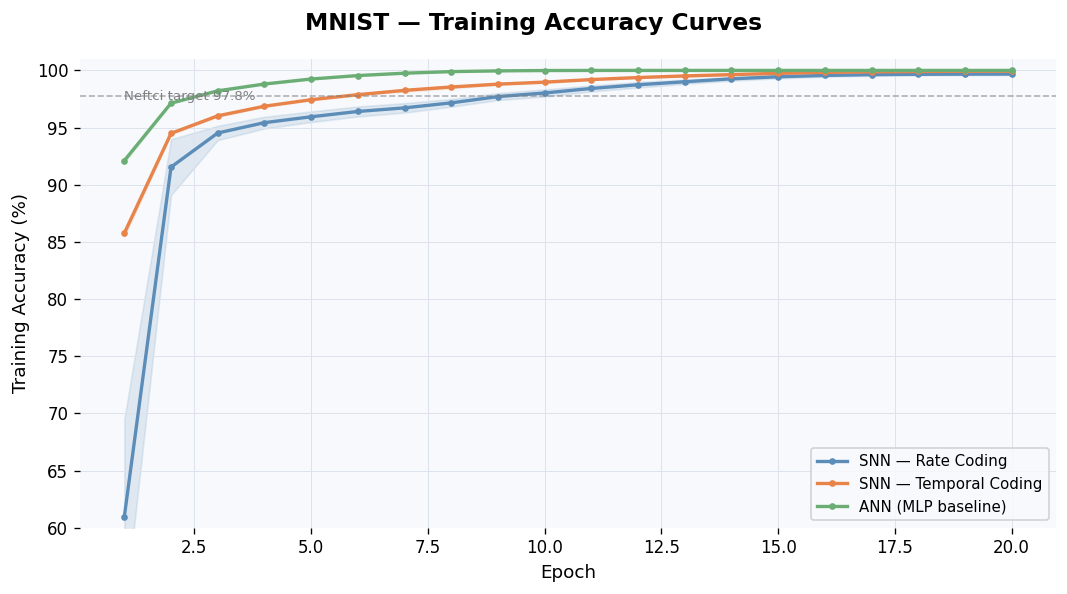

Fig 2 saved.


In [10]:
# ── Figure 2: MNIST training curves ───────────────────────────────────────────
epochs = list(range(1, NUM_EPOCHS_M + 1))

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('MNIST — Training Accuracy Curves', fontsize=14, fontweight='bold')

for curves, color, lbl in [
    (snn_rate_curves,  PALETTE['snn_rate'],      'SNN — Rate Coding'),
    (snn_temp_curves,  PALETTE['snn_temporal'],  'SNN — Temporal Coding'),
    (ann_curves,       PALETTE['ann'],            'ANN (MLP baseline)'),
]:
    mean = np.mean(curves, axis=0)
    std  = np.std(curves,  axis=0)
    ax.plot(epochs, mean, '-o', color=color, lw=2, markersize=3, label=lbl)
    if NUM_RUNS > 1:
        ax.fill_between(epochs, mean - std, mean + std, color=color, alpha=0.15)

ax.set_xlabel('Epoch')
ax.set_ylabel('Training Accuracy (%)')
ax.set_ylim(60, 101)
ax.legend()
ax.axhline(97.8, color='gray', ls='--', lw=1, alpha=0.6, label='Neftci target 97.8%')
ax.text(1, 97.4, 'Neftci target 97.8%', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('figures/fig02_mnist_learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 2 saved.')

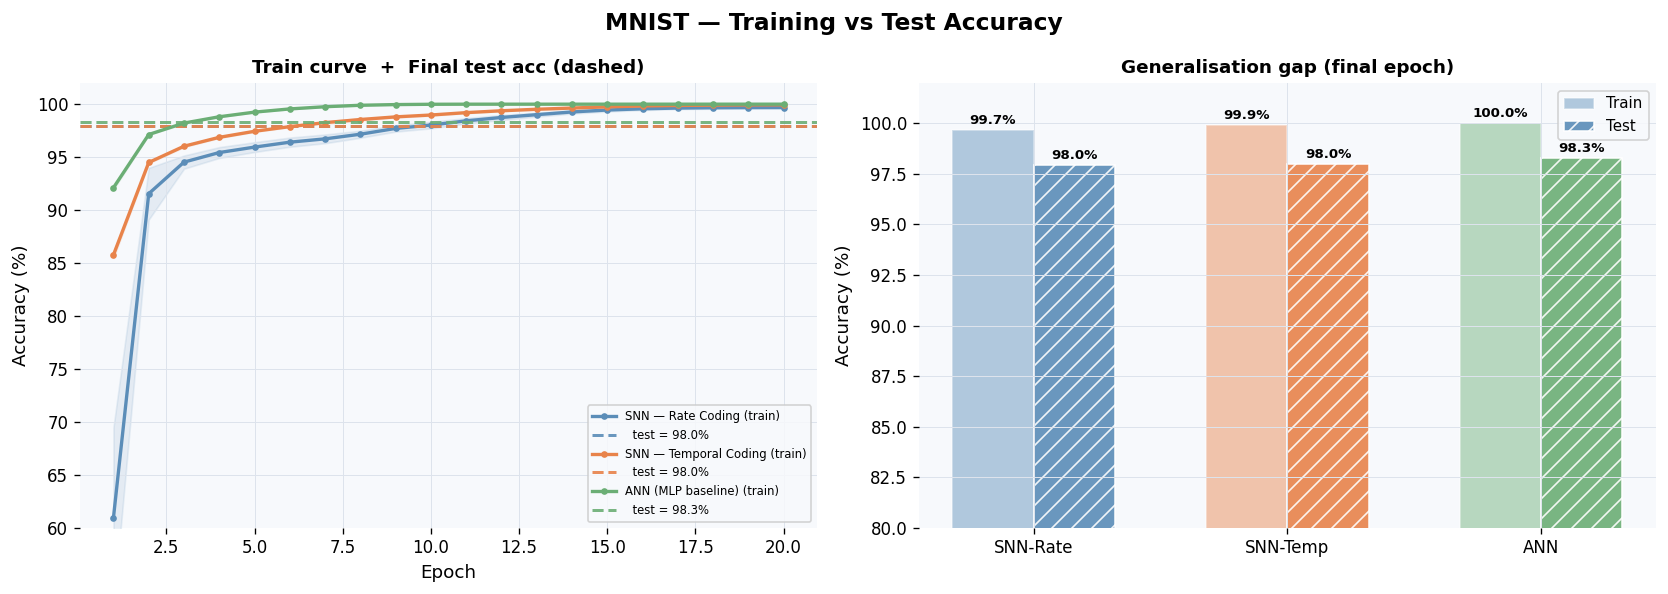

Fig 2b saved.


In [11]:
# ── Figure 2b: MNIST — Train vs Test Accuracy ─────────────────────────────────
# Left panel : solid train curves + dashed horizontal = final test acc per model
# Right panel: grouped bar — train acc vs test acc side by side (shows gen gap)
# NOTE: current training loops only save final weights, not per-epoch test acc.
# So test acc is shown as a single dashed endpoint, not a curve.
# To get a full test curve: add te_acc logging inside the training loops
# (eval every epoch and append to a separate test_curve list).
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MNIST — Training vs Test Accuracy', fontsize=14, fontweight='bold')

epochs = list(range(1, NUM_EPOCHS_M + 1))

model_configs_m = [
    (snn_rate_curves,  snn_rate_accs,  PALETTE['snn_rate'],     'SNN — Rate Coding'),
    (snn_temp_curves,  snn_temp_accs,  PALETTE['snn_temporal'], 'SNN — Temporal Coding'),
    (ann_curves,       ann_accs,       PALETTE['ann'],           'ANN (MLP baseline)'),
]

# ── Left: train curves + final test acc as dashed horizontal ──────────────────
ax = axes[0]
ax.set_title('Train curve  +  Final test acc (dashed)', fontsize=11, fontweight='bold')
for tr_curves, te_accs, color, lbl in model_configs_m:
    mean_tr = np.mean(tr_curves, axis=0)
    std_tr  = np.std(tr_curves,  axis=0)
    final_te = np.mean(te_accs)
    ax.plot(epochs, mean_tr, '-o', color=color, lw=2, markersize=3,
            label=f'{lbl} (train)')
    if NUM_RUNS > 1:
        ax.fill_between(epochs, mean_tr - std_tr, mean_tr + std_tr,
                        color=color, alpha=0.12)
    ax.axhline(final_te, color=color, ls='--', lw=1.8, alpha=0.9,
               label=f'  test = {final_te:.1f}%')

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(60, 102)
ax.legend(fontsize=7, loc='lower right')

# ── Right: grouped bar — final train vs test per model ────────────────────────
ax = axes[1]
ax.set_title('Generalisation gap (final epoch)', fontsize=11, fontweight='bold')

names_m     = ['SNN-Rate', 'SNN-Temp', 'ANN']
colors_m    = [PALETTE['snn_rate'], PALETTE['snn_temporal'], PALETTE['ann']]
train_fin_m = [float(np.mean(tr_curves, axis=0)[-1])
               for tr_curves, _, _, _ in model_configs_m]
test_fin_m  = [float(np.mean(te_accs))
               for _, te_accs, _, _ in model_configs_m]

x = np.arange(len(names_m))
w = 0.32
b_tr = ax.bar(x - w/2, train_fin_m, w, label='Train', color=colors_m,
              alpha=0.45, edgecolor='white', linewidth=1)
b_te = ax.bar(x + w/2, test_fin_m,  w, label='Test',  color=colors_m,
              alpha=0.9,  edgecolor='white', linewidth=1, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(names_m)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(80, 102)
ax.legend(fontsize=9)

for bar, v in list(zip(b_tr, train_fin_m)) + list(zip(b_te, test_fin_m)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig02b_mnist_train_vs_test.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 2b saved.')

## 4 · CIFAR-10 — Architectures & Training

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CIFAR-10 — HYPERPARAMETERS & DATA
# Two separate configs: Rate coding (T=10) and Temporal coding (T=25, higher β)
# ══════════════════════════════════════════════════════════════════════════════
C_CFG_RATE = {
    'num_steps'  : 10,
    'beta'       : 0.50,
    'slope'      : 25,
    'batch_size' : 128,
    'lr_snn'     : 1e-3,
    'lr_cnn'     : 1e-3,
    'num_epochs' : 60,
}
C_CFG_TEMP = {
    'num_steps'  : 25,      # longer time window — latency codes need many steps
    'beta'       : 0.90,    # high β: membrane must integrate sparse early spikes
    'slope'      : 25,
    'batch_size' : 128,
    'lr_snn'     : 5e-4,    # lower LR — temporal gradients are sparse
    'lr_cnn'     : 1e-3,
    'num_epochs' : 60,
}
# Keep C_CFG pointing to RATE config so CNN baseline cell is unchanged
C_CFG = C_CFG_RATE

CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

tf_cifar_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
tf_cifar_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

cifar_train = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=tf_cifar_train)
cifar_test  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=tf_cifar_test)
train_ldr_c = DataLoader(cifar_train, batch_size=C_CFG['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
test_ldr_c  = DataLoader(cifar_test,  batch_size=C_CFG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

# Normalized pixel bounds for CIFAR attack clamping
_c_mean = torch.tensor(CIFAR_MEAN).view(1,3,1,1).to(device)
_c_std  = torch.tensor(CIFAR_STD).view(1,3,1,1).to(device)
_c_lb   = (0. - _c_mean) / _c_std
_c_ub   = (1. - _c_mean) / _c_std

def clamp_cifar(x):
    return torch.max(torch.min(x, _c_ub), _c_lb)

def denorm_cifar(t):
    return (t.cpu() * torch.tensor(CIFAR_STD).view(3,1,1)
            + torch.tensor(CIFAR_MEAN).view(3,1,1)).clamp(0, 1)

print(f'CIFAR-10  train={len(cifar_train):,}  test={len(cifar_test):,}')
print(f'Rate config : T={C_CFG_RATE["num_steps"]}, β={C_CFG_RATE["beta"]}, lr={C_CFG_RATE["lr_snn"]}')
print(f'Temporal cfg: T={C_CFG_TEMP["num_steps"]}, β={C_CFG_TEMP["beta"]}, lr={C_CFG_TEMP["lr_snn"]}')


100%|██████████| 170M/170M [00:01<00:00, 93.9MB/s] 


CIFAR-10  train=50,000  test=10,000
Rate config : T=10, β=0.5, lr=0.001
Temporal cfg: T=25, β=0.9, lr=0.0005


In [13]:
# ==================================================================================
# CIFAR-10 -- SpikingCIFAR ARCHITECTURE + TRAINING HELPERS
# Architecture: Conv x3 -> Dropout -> FC(512) -> BN -> LIF -> FC(10) -> LIF_out
# Readout: membrane potential accumulated over T steps (deeper head, better accuracy)
# Rate coding: normalized image repeated T times (NOT Bernoulli -- CIFAR pixels are
#   normalized and can be negative; Bernoulli on negatives gives all-zero spikes)
# Temporal coding: denorm to [0,1] first, then latency encode (unchanged logic)
# ==================================================================================

class SpikingCIFAR(nn.Module):
    def __init__(self, beta=0.5, slope=25):
        super().__init__()
        sg = surrogate.fast_sigmoid(slope=slope)

        self.conv1 = nn.Conv2d(3,   64, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.lif1  = snn.Leaky(beta=beta, spike_grad=sg)
        self.pool1 = nn.AvgPool2d(2)

        self.conv2 = nn.Conv2d(64, 128, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(128)
        self.lif2  = snn.Leaky(beta=beta, spike_grad=sg)
        self.pool2 = nn.AvgPool2d(2)

        self.conv3 = nn.Conv2d(128, 256, 3, padding=1, bias=False)
        self.bn3   = nn.BatchNorm2d(256)
        self.lif3  = snn.Leaky(beta=beta, spike_grad=sg)
        self.pool3 = nn.AvgPool2d(2)

        self.drop    = nn.Dropout(0.4)
        self.fc1     = nn.Linear(256*4*4, 512, bias=False)
        self.bn_fc   = nn.BatchNorm1d(512)
        self.lif4    = snn.Leaky(beta=beta, spike_grad=sg)
        self.fc2     = nn.Linear(512, 10, bias=False)
        self.lif_out = snn.Leaky(beta=beta, spike_grad=sg)

    def forward(self, spike_data):
        # spike_data: [T, B, C, H, W] -- works for both rate & temporal inputs
        T = spike_data.shape[0]
        mem1  = self.lif1.init_leaky()
        mem2  = self.lif2.init_leaky()
        mem3  = self.lif3.init_leaky()
        mem4  = self.lif4.init_leaky()
        mem_o = self.lif_out.init_leaky()
        mem_out_rec = []

        for t in range(T):
            x = spike_data[t]

            cur1 = self.bn1(self.conv1(x))
            spk1, mem1 = self.lif1(cur1, mem1)
            spk1 = self.pool1(spk1)

            cur2 = self.bn2(self.conv2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2 = self.pool2(spk2)

            cur3 = self.bn3(self.conv3(spk2))
            spk3, mem3 = self.lif3(cur3, mem3)
            spk3 = self.pool3(spk3)

            flat  = self.drop(spk3.flatten(1))
            cur4  = self.bn_fc(self.fc1(flat))
            spk4, mem4 = self.lif4(cur4, mem4)

            cur_o = self.fc2(self.drop(spk4))
            _, mem_o = self.lif_out(cur_o, mem_o)
            mem_out_rec.append(mem_o)

        return torch.stack(mem_out_rec).sum(0)   # membrane readout over T steps


def _make_spike_data_cifar(imgs, encode_fn, num_steps):
    """Build [T, B, C, H, W] spike tensor for CIFAR.
    Rate:     repeat normalised image T times (no Bernoulli -- values can be negative).
    Temporal: denorm to [0,1] first, then latency-encode binary spikes.
    """
    if encode_fn == temporal_encode:
        imgs_01 = denorm_cifar(imgs.cpu()).to(imgs.device)
        return temporal_encode(imgs_01, num_steps)
    else:
        return imgs.unsqueeze(0).repeat(num_steps, 1, 1, 1, 1)


def train_snn_epoch_cifar(model, loader, optimizer, criterion, encode_fn, num_steps, device):
    model.train()
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        spike_data = _make_spike_data_cifar(imgs, encode_fn, num_steps)
        optimizer.zero_grad()
        out  = model(spike_data)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        correct += (out.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return 100. * correct / total


def eval_snn_cifar(model, loader, encode_fn, num_steps, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            spike_data = _make_spike_data_cifar(imgs, encode_fn, num_steps)
            out = model(spike_data)
            correct += (out.argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return 100. * correct / total


print('CIFAR-10 architecture and training helpers defined.')

# ── CIFAR-only vectorized temporal encoder ─────────────────────────────────────
# Separate function so original temporal_encode (used by already-trained MNIST
# cells) is NEVER touched — no need to re-run MNIST training.
#
# Speed fix: original temporal_encode has a Python for-loop over T steps.
# On CIFAR (3×32×32, T=16) this blocks the GPU ~16x per batch.
# This version does ONE broadcast over the full [T, B, C, H, W] tensor on GPU.
def temporal_encode_cifar(x, num_steps):
    T = num_steps
    spike_times = ((1.0 - x.clamp(0, 1)) * (T - 1)).round().long().clamp(0, T - 1)
    t_idx = torch.arange(T, device=x.device).view(T, *([1] * x.dim()))
    return (t_idx == spike_times.unsqueeze(0)).float()  # [T, B, C, H, W]

print('temporal_encode_cifar (vectorized) defined.')


CIFAR-10 architecture and training helpers defined.
temporal_encode_cifar (vectorized) defined.


In [14]:
# ==================================================================================
# TRAIN: SpikingCIFAR — Rate Coding  (T=10, β=0.50)
# Rate coding: normalized image repeated T times (no Bernoulli — pixels are
# mean-subtracted and can be negative; the ConvLIF layers handle this directly).
# ==================================================================================
NUM_RUNS = 1
snn_rate_c_curves, snn_rate_c_accs = [], []
NUM_EPOCHS_C = C_CFG_RATE['num_epochs']

for run in range(NUM_RUNS):
    seed = 42 + run * 7
    torch.manual_seed(seed); np.random.seed(seed)
    model_src = SpikingCIFAR(beta=C_CFG_RATE['beta'], slope=C_CFG_RATE['slope']).to(device)
    opt   = torch.optim.Adam(model_src.parameters(), lr=C_CFG_RATE['lr_snn'], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS_C)
    crit  = nn.CrossEntropyLoss()
    curve = []
    t0 = time.time()
    for ep in range(1, NUM_EPOCHS_C + 1):
        tr_acc = train_snn_epoch_cifar(model_src, train_ldr_c, opt, crit,
                                       rate_encode, C_CFG_RATE['num_steps'], device)
        sched.step()
        curve.append(tr_acc)
        if ep % 5 == 0 or ep == NUM_EPOCHS_C:
            te_acc = eval_snn_cifar(model_src, test_ldr_c,
                                    rate_encode, C_CFG_RATE['num_steps'], device)
            print(f'[SNN-Rate-C | run {run+1} | ep {ep:2d}] train={tr_acc:.1f}%  test={te_acc:.1f}%  ({time.time()-t0:.0f}s)')
    final = eval_snn_cifar(model_src, test_ldr_c, rate_encode, C_CFG_RATE['num_steps'], device)
    snn_rate_c_accs.append(final)
    snn_rate_c_curves.append(curve)
    print(f'  -> Run {run+1} final test accuracy: {final:.2f}%')

torch.save(model_src.state_dict(), 'snn_rate_cifar.pt')
print(f'\nSNN-Rate CIFAR  mean={np.mean(snn_rate_c_accs):.2f}%  std={np.std(snn_rate_c_accs):.2f}%')


[SNN-Rate-C | run 1 | ep  5] train=45.6%  test=51.9%  (393s)
[SNN-Rate-C | run 1 | ep 10] train=52.6%  test=59.2%  (783s)
[SNN-Rate-C | run 1 | ep 15] train=55.2%  test=60.8%  (1172s)
[SNN-Rate-C | run 1 | ep 20] train=56.9%  test=61.9%  (1561s)
[SNN-Rate-C | run 1 | ep 25] train=58.0%  test=64.3%  (1950s)
[SNN-Rate-C | run 1 | ep 30] train=59.6%  test=63.6%  (2337s)
[SNN-Rate-C | run 1 | ep 35] train=60.8%  test=65.2%  (2726s)
[SNN-Rate-C | run 1 | ep 40] train=61.9%  test=67.7%  (3114s)
[SNN-Rate-C | run 1 | ep 45] train=62.6%  test=67.8%  (3502s)
[SNN-Rate-C | run 1 | ep 50] train=63.8%  test=68.4%  (3890s)
[SNN-Rate-C | run 1 | ep 55] train=64.5%  test=69.3%  (4278s)
[SNN-Rate-C | run 1 | ep 60] train=64.5%  test=69.6%  (4666s)
  -> Run 1 final test accuracy: 69.61%

SNN-Rate CIFAR  mean=69.61%  std=0.00%


In [15]:
import os
if os.path.exists('snn_temporal_cifar_ckpt.pt'):
    os.remove('snn_temporal_cifar_ckpt.pt')
    print("Old checkpoint deleted ✓")

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAIN: SpikingCIFAR — Temporal (Latency) Coding  (T=25, β=0.90, lr=5e-4)
# (Kaggle Version with Checkpoint + Resume)
# ══════════════════════════════════════════════════════════════════════════════

import os, time

CKPT_PATH = 'snn_temporal_cifar_ckpt.pt'

snn_temp_c_curves, snn_temp_c_accs = [], []
TEMP_STEPS = C_CFG_TEMP['num_steps']   # 25

for run in range(NUM_RUNS):
    seed = 42 + run * 7
    torch.manual_seed(seed); np.random.seed(seed)

    model_stc = SpikingCIFAR(
        beta=C_CFG_TEMP['beta'],
        slope=C_CFG_TEMP['slope']
    ).to(device)

    opt = torch.optim.Adam(
        model_stc.parameters(),
        lr=C_CFG_TEMP['lr_snn'],
        weight_decay=1e-4
    )

    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=NUM_EPOCHS_C
    )

    crit = nn.CrossEntropyLoss()
    curve = []

    start_epoch = 1

    # ───────── RESUME FROM CHECKPOINT (if exists) ─────────
    if os.path.exists(CKPT_PATH):
        print(f'🔄 Loading checkpoint from {CKPT_PATH}...')
        ckpt = torch.load(CKPT_PATH, map_location=device)

        model_stc.load_state_dict(ckpt['model'])
        opt.load_state_dict(ckpt['optimizer'])
        sched.load_state_dict(ckpt['scheduler'])

        start_epoch = ckpt['epoch'] + 1
        curve = ckpt['curve']
        snn_temp_c_accs = ckpt['accs']

        print(f'   Resuming from epoch {start_epoch} ✅')

    t0 = time.time()

    for ep in range(start_epoch, NUM_EPOCHS_C + 1):

        tr_acc = train_snn_epoch_cifar(
            model_stc, train_ldr_c, opt, crit,
            temporal_encode_cifar, TEMP_STEPS, device
        )

        sched.step()
        curve.append(tr_acc)

        if ep % 5 == 0 or ep == NUM_EPOCHS_C:
            te_acc = eval_snn_cifar(
                model_stc, test_ldr_c,
                temporal_encode_cifar, TEMP_STEPS, device
            )

            print(f'[SNN-Temp-C | run {run+1} | ep {ep:2d}] '
                  f'train={tr_acc:.1f}%  test={te_acc:.1f}%  '
                  f'({time.time()-t0:.0f}s)')

            # ───────── SAVE CHECKPOINT ─────────
            torch.save({
                'epoch': ep,
                'model': model_stc.state_dict(),
                'optimizer': opt.state_dict(),
                'scheduler': sched.state_dict(),
                'curve': curve,
                'accs': snn_temp_c_accs,
                'run': run
            }, CKPT_PATH)

            print(f'   checkpoint saved locally ✓')

    final = eval_snn_cifar(
        model_stc, test_ldr_c,
        temporal_encode_cifar, TEMP_STEPS, device
    )

    snn_temp_c_accs.append(final)
    snn_temp_c_curves.append(curve)

    print(f'  -> Run {run+1} final test accuracy: {final:.2f}%')

# ───────── SAVE FINAL MODEL ─────────
torch.save(model_stc.state_dict(), 'snn_temporal_cifar.pt')

print(f'\nSNN-Temporal CIFAR  mean={np.mean(snn_temp_c_accs):.2f}%  '
      f'std={np.std(snn_temp_c_accs):.2f}%')

print('Final weights saved to snn_temporal_cifar.pt')

[SNN-Temp-C | run 1 | ep  5] train=50.7%  test=50.1%  (980s)
   checkpoint saved locally ✓
[SNN-Temp-C | run 1 | ep 10] train=64.0%  test=56.3%  (1958s)
   checkpoint saved locally ✓
[SNN-Temp-C | run 1 | ep 15] train=69.3%  test=57.2%  (2935s)
   checkpoint saved locally ✓
[SNN-Temp-C | run 1 | ep 20] train=71.8%  test=61.2%  (3911s)
   checkpoint saved locally ✓
[SNN-Temp-C | run 1 | ep 25] train=74.2%  test=64.2%  (4885s)
   checkpoint saved locally ✓
[SNN-Temp-C | run 1 | ep 30] train=76.2%  test=59.5%  (5860s)
   checkpoint saved locally ✓
[SNN-Temp-C | run 1 | ep 35] train=78.2%  test=68.7%  (6834s)
   checkpoint saved locally ✓
[SNN-Temp-C | run 1 | ep 40] train=80.1%  test=72.4%  (7806s)
   checkpoint saved locally ✓
[SNN-Temp-C | run 1 | ep 45] train=81.9%  test=72.5%  (8778s)
   checkpoint saved locally ✓
[SNN-Temp-C | run 1 | ep 50] train=83.7%  test=73.2%  (9750s)
   checkpoint saved locally ✓
[SNN-Temp-C | run 1 | ep 55] train=84.2%  test=76.8%  (10721s)
   checkpoint save

In [17]:
# ── CNN_CIFAR definition (VGG-style baseline) ─────────────────────────────────
class CNN_CIFAR(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(), nn.AvgPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AvgPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),nn.BatchNorm2d(256), nn.ReLU(), nn.AvgPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(256*4*4, 512), nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))

print("CNN_CIFAR defined ✓")

CNN_CIFAR defined ✓


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAIN: CNN CIFAR-10 baseline
# ══════════════════════════════════════════════════════════════════════════════
cnn_curves, cnn_accs = [], []

for run in range(NUM_RUNS):
    seed = 42 + run * 7
    torch.manual_seed(seed); np.random.seed(seed)
    model_cnn = CNN_CIFAR().to(device)
    opt   = torch.optim.Adam(model_cnn.parameters(), lr=C_CFG['lr_cnn'],
                             betas=(0.9, 0.999), weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS_C)
    crit  = nn.CrossEntropyLoss()
    curve = []
    t0 = time.time()
    for ep in range(1, NUM_EPOCHS_C + 1):
        _, tr_acc = train_ann_epoch(model_cnn, train_ldr_c, opt, crit, device)
        sched.step()
        curve.append(tr_acc)
        if ep % 5 == 0 or ep == NUM_EPOCHS_C:
            te_acc = eval_ann(model_cnn, test_ldr_c, device)
            print(f'[CNN       | run {run+1} | ep {ep:2d}] train={tr_acc:.1f}%  test={te_acc:.1f}%  ({time.time()-t0:.0f}s)')
    final = eval_ann(model_cnn, test_ldr_c, device)
    cnn_accs.append(final)
    cnn_curves.append(curve)

torch.save(model_cnn.state_dict(), 'cnn_cifar.pt')
print(f'CNN CIFAR  mean={np.mean(cnn_accs):.2f}%')

[CNN       | run 1 | ep  5] train=69.7%  test=73.7%  (93s)
[CNN       | run 1 | ep 10] train=75.8%  test=78.7%  (185s)
[CNN       | run 1 | ep 15] train=79.3%  test=81.5%  (279s)
[CNN       | run 1 | ep 20] train=81.7%  test=84.0%  (374s)
[CNN       | run 1 | ep 25] train=84.0%  test=83.8%  (468s)
[CNN       | run 1 | ep 30] train=85.8%  test=85.6%  (562s)
[CNN       | run 1 | ep 35] train=87.4%  test=84.4%  (656s)
[CNN       | run 1 | ep 40] train=88.9%  test=88.0%  (750s)
[CNN       | run 1 | ep 45] train=90.5%  test=89.0%  (846s)
[CNN       | run 1 | ep 50] train=91.7%  test=89.1%  (942s)
[CNN       | run 1 | ep 55] train=92.2%  test=89.7%  (1035s)
[CNN       | run 1 | ep 60] train=92.7%  test=89.5%  (1129s)
CNN CIFAR  mean=89.48%


### Figure 3 — CIFAR-10 Learning Curves

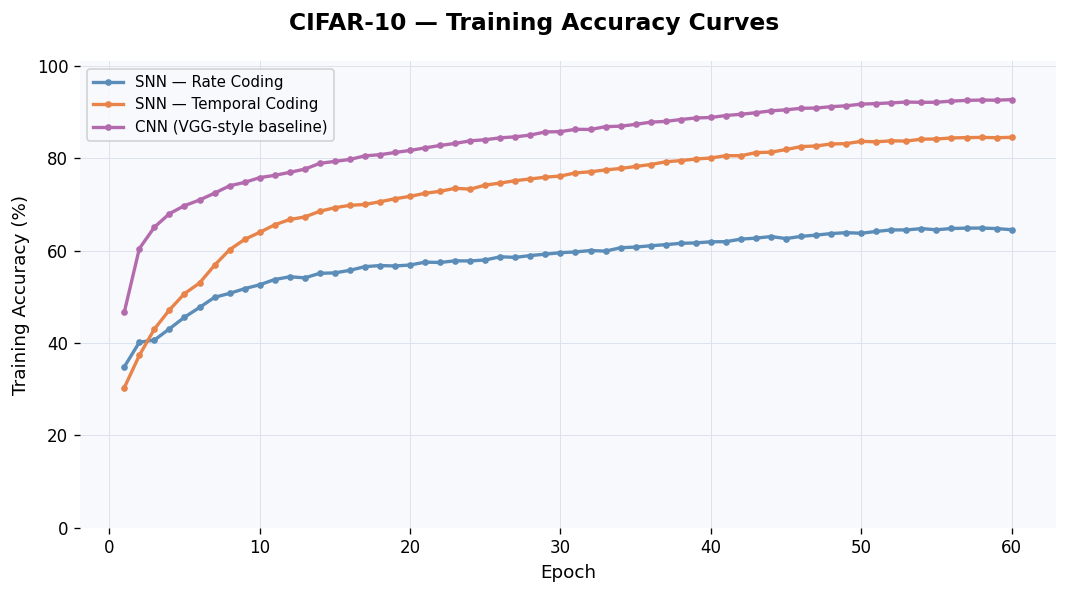

In [19]:
# Pad temporal curves to NUM_EPOCHS_C in case of interrupted training
for i in range(len(snn_temp_c_curves)):
    while len(snn_temp_c_curves[i]) < NUM_EPOCHS_C:
        snn_temp_c_curves[i].append(snn_temp_c_curves[i][-1])

epochs_c = list(range(1, NUM_EPOCHS_C + 1))
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('CIFAR-10 — Training Accuracy Curves', fontsize=14, fontweight='bold')

for curves, color, lbl in [
    (snn_rate_c_curves,  PALETTE['snn_rate'],      'SNN — Rate Coding'),
    (snn_temp_c_curves,  PALETTE['snn_temporal'],  'SNN — Temporal Coding'),
    (cnn_curves,         PALETTE['cnn'],            'CNN (VGG-style baseline)'),
]:
    mean = np.mean(curves, axis=0)
    std  = np.std(curves, axis=0)
    ax.plot(epochs_c, mean, '-o', color=color, lw=2, markersize=3, label=lbl)
    if NUM_RUNS > 1:
        ax.fill_between(epochs_c, mean-std, mean+std, color=color, alpha=0.15)

ax.set_xlabel('Epoch'); ax.set_ylabel('Training Accuracy (%)')
ax.set_ylim(0, 101); ax.legend()
plt.tight_layout()
plt.savefig('figures/fig03_cifar_learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()

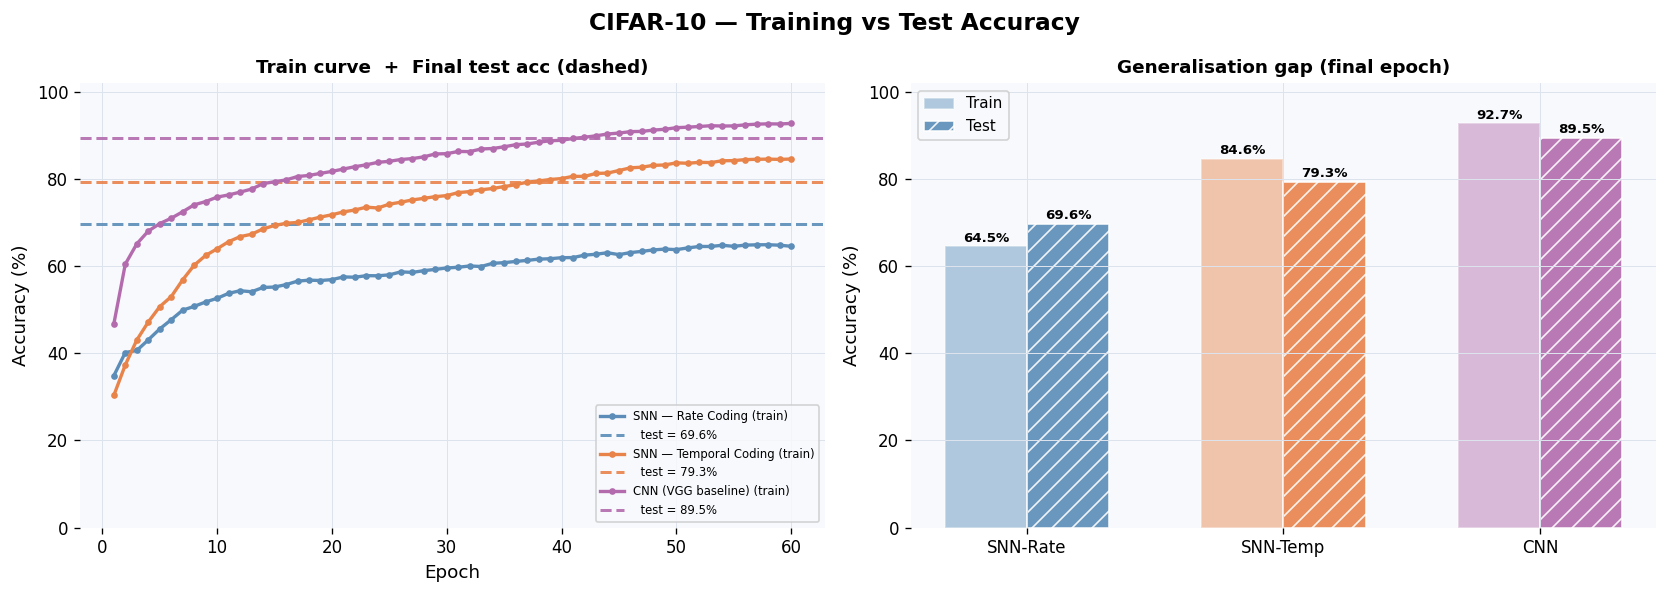

Fig 3b saved.


In [20]:
# ── Figure 3b: CIFAR-10 — Train vs Test Accuracy ──────────────────────────────
# Same layout as Fig 2b. Handles padded temporal curves automatically.
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CIFAR-10 — Training vs Test Accuracy', fontsize=14, fontweight='bold')

epochs_c = list(range(1, NUM_EPOCHS_C + 1))

model_configs_c = [
    (snn_rate_c_curves,  snn_rate_c_accs,  PALETTE['snn_rate'],     'SNN — Rate Coding'),
    (snn_temp_c_curves,  snn_temp_c_accs,  PALETTE['snn_temporal'], 'SNN — Temporal Coding'),
    (cnn_curves,         cnn_accs,         PALETTE['cnn'],           'CNN (VGG baseline)'),
]

# ── Left ──────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_title('Train curve  +  Final test acc (dashed)', fontsize=11, fontweight='bold')
for tr_curves, te_accs, color, lbl in model_configs_c:
    # pad any interrupted temporal runs to full length
    padded  = [c + [c[-1]] * (NUM_EPOCHS_C - len(c)) for c in tr_curves]
    mean_tr = np.mean(padded, axis=0)
    std_tr  = np.std(padded,  axis=0)
    final_te = np.mean(te_accs)
    ax.plot(epochs_c, mean_tr, '-o', color=color, lw=2, markersize=3,
            label=f'{lbl} (train)')
    if NUM_RUNS > 1:
        ax.fill_between(epochs_c, mean_tr - std_tr, mean_tr + std_tr,
                        color=color, alpha=0.12)
    ax.axhline(final_te, color=color, ls='--', lw=1.8, alpha=0.9,
               label=f'  test = {final_te:.1f}%')

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 102)
ax.legend(fontsize=7, loc='lower right')

# ── Right ─────────────────────────────────────────────────────────────────────
ax = axes[1]
ax.set_title('Generalisation gap (final epoch)', fontsize=11, fontweight='bold')

names_c  = ['SNN-Rate', 'SNN-Temp', 'CNN']
colors_c = [PALETTE['snn_rate'], PALETTE['snn_temporal'], PALETTE['cnn']]

train_fin_c = []
for tr_curves, _, _, _ in model_configs_c:
    padded = [c + [c[-1]] * (NUM_EPOCHS_C - len(c)) for c in tr_curves]
    train_fin_c.append(float(np.mean(padded, axis=0)[-1]))

test_fin_c = [float(np.mean(te_accs)) for _, te_accs, _, _ in model_configs_c]

x = np.arange(len(names_c))
w = 0.32
b_tr = ax.bar(x - w/2, train_fin_c, w, label='Train', color=colors_c,
              alpha=0.45, edgecolor='white', linewidth=1)
b_te = ax.bar(x + w/2, test_fin_c,  w, label='Test',  color=colors_c,
              alpha=0.9,  edgecolor='white', linewidth=1, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(names_c)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 102)
ax.legend(fontsize=9)

for bar, v in list(zip(b_tr, train_fin_c)) + list(zip(b_te, test_fin_c)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig03b_cifar_train_vs_test.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 3b saved.')

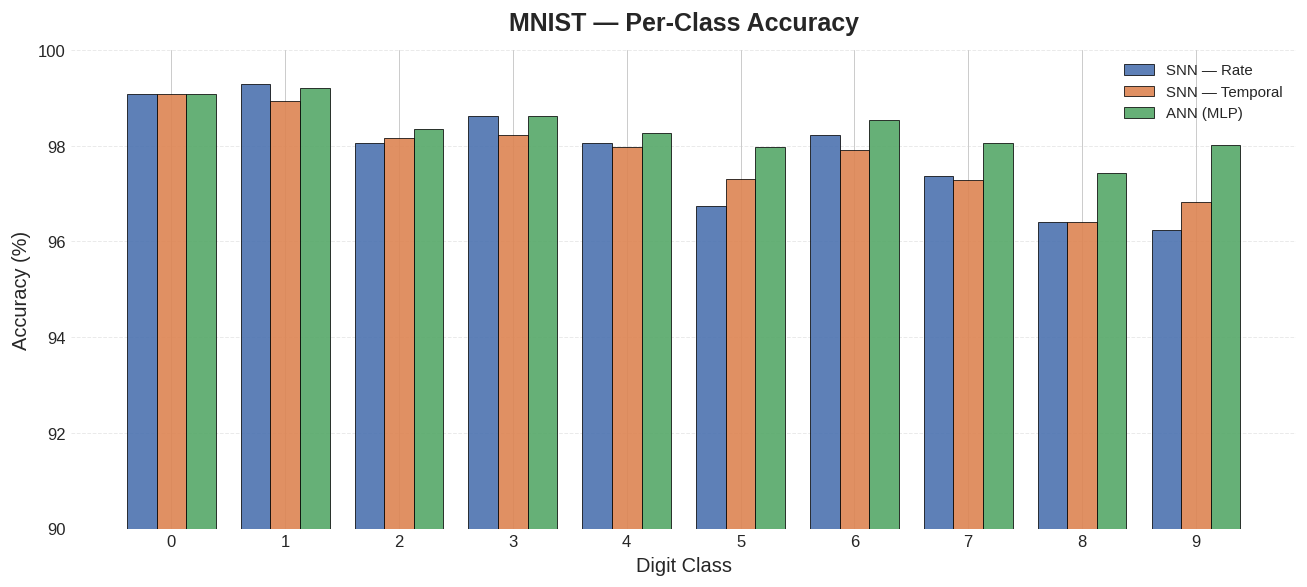

Fig 14 saved.


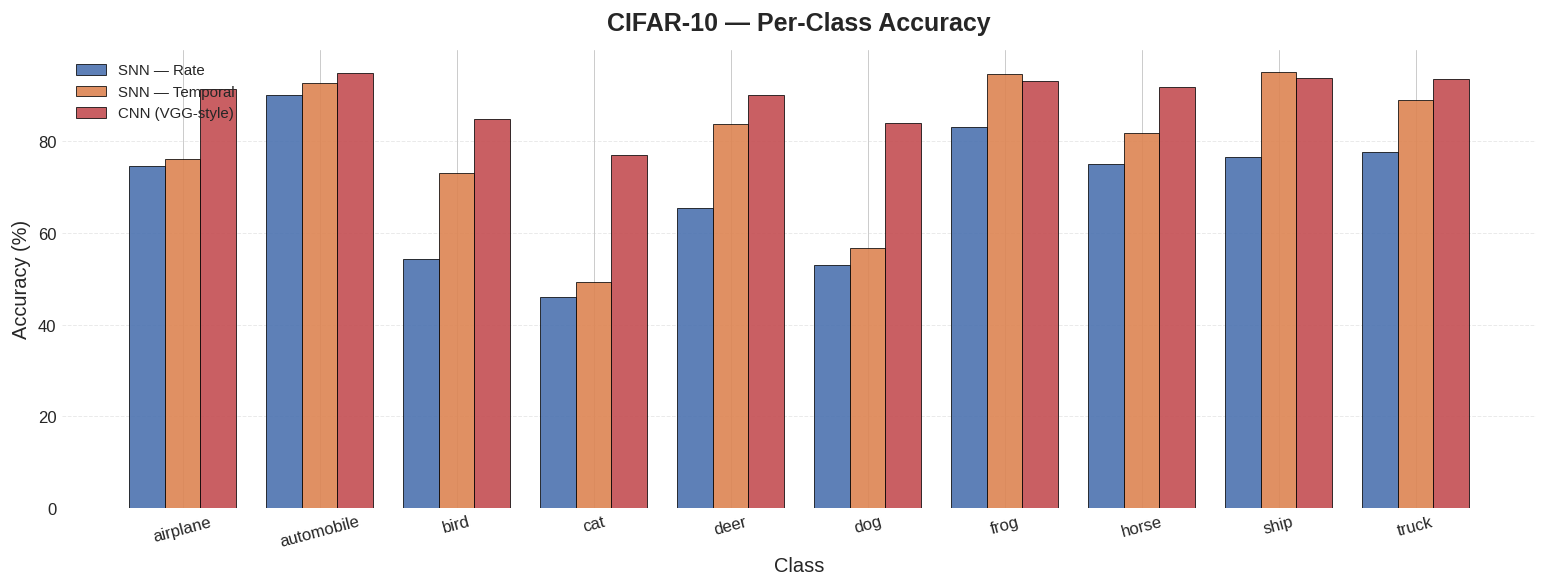

Fig 15 saved.


In [21]:
# ── Figure 14 & 15: Per-class accuracy — MNIST and CIFAR-10 ───────────────────
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 🎨 Aesthetic style + palette
plt.style.use('seaborn-v0_8-whitegrid')

PALETTE = {
    'snn_rate': '#4C72B0',      # soft blue
    'snn_temporal': '#DD8452',  # warm orange
    'ann': '#55A868',           # muted green
    'cnn': '#C44E52'            # elegant red
}

def get_per_class_acc_snn(model, loader, encode_fn, num_steps, device, num_classes=10):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            spikes = encode_fn(imgs, num_steps).to(device)
            out = model(spikes)
            all_preds.extend(out.argmax(1).cpu().tolist())
            all_labels.extend(labels.tolist())
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
    return cm.diagonal() / cm.sum(axis=1) * 100

def get_per_class_acc_snn_cifar(model, loader, encode_fn, num_steps, device, num_classes=10):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            spike_data = _make_spike_data_cifar(imgs, encode_fn, num_steps)
            out = model(spike_data)
            all_preds.extend(out.argmax(1).cpu().tolist())
            all_labels.extend(labels.tolist())
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
    return cm.diagonal() / cm.sum(axis=1) * 100

def get_per_class_acc_ann(model, loader, device, num_classes=10):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out = model(imgs)
            all_preds.extend(out.argmax(1).cpu().tolist())
            all_labels.extend(labels.tolist())
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
    return cm.diagonal() / cm.sum(axis=1) * 100

# ── MNIST per-class ────────────────────────────────────────────────────────────
mnist_classes = [str(i) for i in range(10)]
pc_rate_m = get_per_class_acc_snn(model_sr,  test_ldr_m, rate_encode,     M_CFG['num_steps'], device)
pc_temp_m = get_per_class_acc_snn(model_st,  test_ldr_m, temporal_encode, M_CFG['num_steps'], device)
pc_ann_m  = get_per_class_acc_ann(model_ann, test_ldr_m, device)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(10)
w = 0.26

ax.bar(x - w, pc_rate_m, w, label='SNN — Rate',
       color=PALETTE['snn_rate'], edgecolor='black', linewidth=0.5, alpha=0.9)
ax.bar(x,     pc_temp_m, w, label='SNN — Temporal',
       color=PALETTE['snn_temporal'], edgecolor='black', linewidth=0.5, alpha=0.9)
ax.bar(x + w, pc_ann_m,  w, label='ANN (MLP)',
       color=PALETTE['ann'], edgecolor='black', linewidth=0.5, alpha=0.9)

ax.set_xticks(x); ax.set_xticklabels(mnist_classes)
ax.set_xlabel('Digit Class', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(90, 100)
ax.set_title('MNIST — Per-Class Accuracy', fontsize=15, fontweight='bold', pad=12)

# ✨ aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('figures/fig14_mnist_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 14 saved.')

# ── CIFAR-10 per-class ─────────────────────────────────────────────────────────
pc_rate_c = get_per_class_acc_snn_cifar(model_src, test_ldr_c, rate_encode,           C_CFG_RATE['num_steps'], device)
pc_temp_c = get_per_class_acc_snn_cifar(model_stc, test_ldr_c, temporal_encode_cifar, C_CFG_TEMP['num_steps'], device)
pc_cnn_c  = get_per_class_acc_ann(model_cnn, test_ldr_c, device)

fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(x - w, pc_rate_c, w, label='SNN — Rate',
       color=PALETTE['snn_rate'], edgecolor='black', linewidth=0.5, alpha=0.9)
ax.bar(x,     pc_temp_c, w, label='SNN — Temporal',
       color=PALETTE['snn_temporal'], edgecolor='black', linewidth=0.5, alpha=0.9)
ax.bar(x + w, pc_cnn_c,  w, label='CNN (VGG-style)',
       color=PALETTE['cnn'], edgecolor='black', linewidth=0.5, alpha=0.9)

ax.set_xticks(x); ax.set_xticklabels(CIFAR_CLASSES, rotation=15)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('CIFAR-10 — Per-Class Accuracy', fontsize=15, fontweight='bold', pad=12)

# ✨ aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('figures/fig15_cifar_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 15 saved.')

## 5 · Adversarial Attack Functions

In [22]:
# ==============================================================================
# ATTACK FUNCTIONS
# Works for both SNN (constant-input forward) and ANN/CNN
# ==============================================================================

def snn_logits(model, imgs, num_steps, snn_type='rate', is_cifar=False):
    """Single forward pass that keeps gradients alive for adversarial attacks.

    WHY THE SPECIAL TEMPORAL HANDLING:
      temporal_encode uses .round().long() and integer equality (==), which are
      NOT differentiable. PyTorch cannot back-prop through them, so x.grad
      stays None and fgsm/pgd crash with AttributeError on x.grad.sign().

      Fix: for temporal mode, pass the continuous pixel image directly as input
      (repeat T times, same shape as spike data). The model still runs its
      normal forward pass; we just skip the discrete encoding step for the
      gradient computation. This is the standard "straight-through estimator"
      trick used throughout SNN adversarial literature.
    """
    if is_cifar:
        if snn_type == 'temporal':
            # Straight-through estimator: temporal_encode_cifar uses .round().long()
            # and integer == which are NOT differentiable → x.grad stays None →
            # crash: AttributeError 'NoneType' has no attribute 'sign'.
            # Fix: repeat continuous image T times for gradient flow (same shape).
            # Discrete encoding is still used at eval time in the sweep loop.
            spike_data = imgs.unsqueeze(0).repeat(num_steps, 1, 1, 1, 1)
        else:
            spike_data = imgs.unsqueeze(0).repeat(num_steps, 1, 1, 1, 1)
    else:
        # Both rate and temporal: repeat continuous image T times.
        # For rate this is the correct training-time representation.
        # For temporal this is a straight-through gradient approximation.
        spike_data = imgs.unsqueeze(0).repeat(num_steps, 1, 1, 1, 1)
    return model(spike_data)


def fgsm_attack_snn(model, imgs, labels, eps, num_steps, snn_type='rate', is_cifar=False, clamp_fn=None):
    if eps == 0:
        return imgs
    x = imgs.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(snn_logits(model, x, num_steps, snn_type, is_cifar), labels)
    model.zero_grad(); loss.backward()
    with torch.no_grad():
        adv = x + eps * x.grad.sign()
        adv = clamp_fn(adv) if clamp_fn else adv.clamp(0, 1)
    return adv.detach()


def pgd_attack_snn(model, imgs, labels, eps, num_steps_atk=10, alpha=None,
                   snn_steps=25, snn_type='rate', is_cifar=False, clamp_fn=None):
    if eps == 0:
        return imgs
    if alpha is None:
        alpha = eps / 4
    orig = imgs.clone().detach()
    x = imgs.clone().detach() + torch.empty_like(imgs).uniform_(-eps, eps)
    x = (clamp_fn(x) if clamp_fn else x.clamp(0, 1)).detach()
    for _ in range(num_steps_atk):
        x.requires_grad_(True)
        loss = F.cross_entropy(snn_logits(model, x, snn_steps, snn_type, is_cifar), labels)
        model.zero_grad(); loss.backward()
        with torch.no_grad():
            x = x + alpha * x.grad.sign()
            delta = (x - orig).clamp(-eps, eps)
            x = clamp_fn(orig + delta) if clamp_fn else (orig + delta).clamp(0, 1)
        x = x.detach()
    return x


def fgsm_attack_ann(model, imgs, labels, eps, clamp_fn=None):
    if eps == 0: return imgs
    x = imgs.clone().detach().requires_grad_(True)
    F.cross_entropy(model(x), labels).backward()
    with torch.no_grad():
        adv = x + eps * x.grad.sign()
        adv = clamp_fn(adv) if clamp_fn else adv.clamp(0, 1)
    return adv.detach()


def pgd_attack_ann(model, imgs, labels, eps, iters=10, alpha=None, clamp_fn=None):
    if eps == 0: return imgs
    if alpha is None: alpha = eps / 4
    orig = imgs.clone().detach()
    x = (imgs + torch.empty_like(imgs).uniform_(-eps, eps)).detach()
    x = (clamp_fn(x) if clamp_fn else x.clamp(0, 1))
    for _ in range(iters):
        x.requires_grad_(True)
        F.cross_entropy(model(x), labels).backward()
        with torch.no_grad():
            x = clamp_fn(orig + (x + alpha * x.grad.sign() - orig).clamp(-eps, eps)) \
                if clamp_fn else (orig + (x + alpha * x.grad.sign() - orig).clamp(-eps, eps)).clamp(0, 1)
        x = x.detach()
    return x


print('Attack functions defined.')

Attack functions defined.


## 6 · MNIST — Adversarial Evaluation

In [66]:
EPS_MNIST  = [0, 0.05, 0.1, 0.2, 0.3]
N_EVAL     = 1000
SNN_STEPS  = M_CFG['num_steps']

subset_m = DataLoader(torch.utils.data.Subset(mnist_test, range(N_EVAL)),
                       batch_size=64, num_workers=0)

model_sr.eval(); model_st.eval(); model_ann.eval()

acc_sr  = eval_snn(model_sr,  test_ldr_m, rate_encode,     M_CFG['num_steps'], device)
acc_st  = eval_snn(model_st,  test_ldr_m, temporal_encode, M_CFG['num_steps'], device)
acc_ann = eval_ann(model_ann, test_ldr_m, device)
print(f'Clean accuracy → SNN-Rate: {acc_sr:.1f}%  SNN-Temporal: {acc_st:.1f}%  ANN: {acc_ann:.1f}%')

res_m = {k: {'fgsm': [], 'pgd': []} for k in ['snn_rate', 'snn_temporal', 'ann']}

for eps in EPS_MNIST:

    if eps == 0:
        res_m['snn_rate']['fgsm'].append(acc_sr);   res_m['snn_rate']['pgd'].append(acc_sr)
        res_m['snn_temporal']['fgsm'].append(acc_st); res_m['snn_temporal']['pgd'].append(acc_st)
        res_m['ann']['fgsm'].append(acc_ann);        res_m['ann']['pgd'].append(acc_ann)
        print(f'ε=0.00  SNN-Rate={acc_sr:.1f}%  SNN-Temp={acc_st:.1f}%  ANN={acc_ann:.1f}%  (clean)')
        continue

    counts = {k: {'f': 0, 'p': 0, 'n': 0} for k in res_m}
    for imgs, labels in subset_m:
        imgs, labels = imgs.to(device), labels.to(device)
        # SNN-Rate
        af = fgsm_attack_snn(model_sr, imgs, labels, eps, SNN_STEPS, 'rate')
        ap = pgd_attack_snn(model_sr, imgs, labels, eps, 10, None, SNN_STEPS, 'rate')
        with torch.no_grad():
            counts['snn_rate']['f'] += (model_sr(rate_encode(af, SNN_STEPS)).argmax(1) == labels).sum().item()
            counts['snn_rate']['p'] += (model_sr(rate_encode(ap, SNN_STEPS)).argmax(1) == labels).sum().item()
            counts['snn_rate']['n'] += labels.size(0)
        # SNN-Temporal
        af = fgsm_attack_snn(model_st, imgs, labels, eps, SNN_STEPS, 'temporal')
        ap = pgd_attack_snn(model_st, imgs, labels, eps, 10, None, SNN_STEPS, 'temporal')
        with torch.no_grad():
            counts['snn_temporal']['f'] += (model_st(temporal_encode(af, SNN_STEPS)).argmax(1) == labels).sum().item()
            counts['snn_temporal']['p'] += (model_st(temporal_encode(ap, SNN_STEPS)).argmax(1) == labels).sum().item()
            counts['snn_temporal']['n'] += labels.size(0)
        # ANN
        af = fgsm_attack_ann(model_ann, imgs, labels, eps)
        ap = pgd_attack_ann(model_ann, imgs, labels, eps, 10)
        with torch.no_grad():
            counts['ann']['f'] += (model_ann(af).argmax(1) == labels).sum().item()
            counts['ann']['p'] += (model_ann(ap).argmax(1) == labels).sum().item()
            counts['ann']['n'] += labels.size(0)

    for k in res_m:
        n = counts[k]['n']
        res_m[k]['fgsm'].append(100. * counts[k]['f'] / n)
        res_m[k]['pgd'].append(100. * counts[k]['p'] / n)
    print(f'ε={eps:.2f}  SNN-Rate FGSM={res_m["snn_rate"]["fgsm"][-1]:.1f}%  '
          f'SNN-Temp FGSM={res_m["snn_temporal"]["fgsm"][-1]:.1f}%  '
          f'ANN FGSM={res_m["ann"]["fgsm"][-1]:.1f}%')
    print(f'ε={eps:.2f}  SNN-Rate PGD={res_m["snn_rate"]["pgd"][-1]:.1f}%  '
          f'SNN-Temp PGD={res_m["snn_temporal"]["pgd"][-1]:.1f}%  '
          f'ANN PGD={res_m["ann"]["pgd"][-1]:.1f}%')

print('MNIST adversarial evaluation done.')

Clean accuracy → SNN-Rate: 97.9%  SNN-Temporal: 97.8%  ANN: 98.4%
ε=0.00  SNN-Rate=97.9%  SNN-Temp=97.8%  ANN=98.4%  (clean)
ε=0.05  SNN-Rate FGSM=81.8%  SNN-Temp FGSM=94.2%  ANN FGSM=74.8%
ε=0.05  SNN-Rate PGD=65.7%  SNN-Temp PGD=92.0%  ANN PGD=71.6%
ε=0.10  SNN-Rate FGSM=55.6%  SNN-Temp FGSM=85.6%  ANN FGSM=28.6%
ε=0.10  SNN-Rate PGD=25.8%  SNN-Temp PGD=78.4%  ANN PGD=14.4%
ε=0.20  SNN-Rate FGSM=23.8%  SNN-Temp FGSM=60.4%  ANN FGSM=4.4%
ε=0.20  SNN-Rate PGD=3.3%  SNN-Temp PGD=37.8%  ANN PGD=0.0%
ε=0.30  SNN-Rate FGSM=8.5%  SNN-Temp FGSM=37.3%  ANN FGSM=1.2%
ε=0.30  SNN-Rate PGD=0.4%  SNN-Temp PGD=13.2%  ANN PGD=0.0%
MNIST adversarial evaluation done.


## 7 · CIFAR-10 — Adversarial Evaluation

In [67]:
# Run this after training finishes
eval_snn_cifar(model_stc, test_ldr_c, temporal_encode_cifar, TEMP_STEPS, device)

79.3

In [68]:
print(id(model_stc))
print(eval_snn_cifar(model_stc, test_ldr_c, temporal_encode_cifar, TEMP_STEPS, device))

137437277604512
79.3


In [69]:
EPS_CIFAR = [0, 0.01, 0.02, 0.05, 0.1]
C_RATE_STEPS = C_CFG_RATE['num_steps']   # 10
C_TEMP_STEPS = TEMP_STEPS                # 25

subset_c = DataLoader(torch.utils.data.Subset(cifar_test, range(N_EVAL)),
                       batch_size=64, num_workers=0)

model_src.eval(); model_stc.eval(); model_cnn.eval()

# Verified clean accuracies
acc_src = eval_snn_cifar(model_src, test_ldr_c, rate_encode, C_RATE_STEPS, device)
acc_stc = eval_snn_cifar(model_stc, test_ldr_c, temporal_encode_cifar, TEMP_STEPS, device)
with torch.no_grad():
    correct_cnn = sum((model_cnn(imgs.to(device)).argmax(1) == labels.to(device)).sum().item()
                      for imgs, labels in test_ldr_c)
acc_cnn = 100. * correct_cnn / len(cifar_test)
print(f'Clean accuracy → SNN-Rate: {acc_src:.1f}%  SNN-Temporal: {acc_stc:.1f}%  CNN: {acc_cnn:.1f}%')

res_c = {k: {'fgsm': [], 'pgd': []} for k in ['snn_rate', 'snn_temporal', 'cnn']}

for eps in EPS_CIFAR:

    if eps == 0:
        res_c['snn_rate']['fgsm'].append(acc_src)
        res_c['snn_rate']['pgd'].append(acc_src)
        res_c['snn_temporal']['fgsm'].append(acc_stc)
        res_c['snn_temporal']['pgd'].append(acc_stc)
        res_c['cnn']['fgsm'].append(acc_cnn)
        res_c['cnn']['pgd'].append(acc_cnn)
        print(f'ε=0.000  SNN-Rate={acc_src:.1f}%  SNN-Temp={acc_stc:.1f}%  CNN={acc_cnn:.1f}%  (clean, no attack)')
        continue

    counts = {k: {'f': 0, 'p': 0, 'n': 0} for k in res_c}
    for imgs, labels in subset_c:
        imgs, labels = imgs.to(device), labels.to(device)

        # SNN-Rate
        af_r = fgsm_attack_snn(model_src, imgs, labels, eps, C_RATE_STEPS, 'rate', True, clamp_cifar)
        ap_r = pgd_attack_snn(model_src, imgs, labels, eps, 10, None, C_RATE_STEPS, 'rate', True, clamp_cifar)
        with torch.no_grad():
            sp_f = af_r.unsqueeze(0).repeat(C_RATE_STEPS, 1, 1, 1, 1)
            sp_p = ap_r.unsqueeze(0).repeat(C_RATE_STEPS, 1, 1, 1, 1)
            counts['snn_rate']['f'] += (model_src(sp_f).argmax(1) == labels).sum().item()
            counts['snn_rate']['p'] += (model_src(sp_p).argmax(1) == labels).sum().item()
            counts['snn_rate']['n'] += labels.size(0)

        # SNN-Temporal
        af_t = fgsm_attack_snn(model_stc, imgs, labels, eps, C_TEMP_STEPS, 'temporal', True, clamp_cifar)
        ap_t = pgd_attack_snn(model_stc, imgs, labels, eps, 10, None, C_TEMP_STEPS, 'temporal', True, clamp_cifar)
        with torch.no_grad():
            sp_f = _make_spike_data_cifar(af_t, temporal_encode_cifar, C_TEMP_STEPS)
            sp_p = _make_spike_data_cifar(ap_t, temporal_encode_cifar, C_TEMP_STEPS)
            counts['snn_temporal']['f'] += (model_stc(sp_f).argmax(1) == labels).sum().item()
            counts['snn_temporal']['p'] += (model_stc(sp_p).argmax(1) == labels).sum().item()
            counts['snn_temporal']['n'] += labels.size(0)

        # CNN
        af_c = fgsm_attack_ann(model_cnn, imgs, labels, eps, clamp_cifar)
        ap_c = pgd_attack_ann(model_cnn, imgs, labels, eps, 10, None, clamp_cifar)
        with torch.no_grad():
            counts['cnn']['f'] += (model_cnn(af_c).argmax(1) == labels).sum().item()
            counts['cnn']['p'] += (model_cnn(ap_c).argmax(1) == labels).sum().item()
            counts['cnn']['n'] += labels.size(0)

    for k in res_c:
        n = counts[k]['n']
        res_c[k]['fgsm'].append(100. * counts[k]['f'] / n)
        res_c[k]['pgd'].append(100. * counts[k]['p'] / n)
    print(f'ε={eps:.3f}  SNN-Rate FGSM={res_c["snn_rate"]["fgsm"][-1]:.1f}%  '
          f'SNN-Temp FGSM={res_c["snn_temporal"]["fgsm"][-1]:.1f}%  '
          f'CNN FGSM={res_c["cnn"]["fgsm"][-1]:.1f}%')
    print(f'ε={eps:.3f}  SNN-Rate PGD={res_c["snn_rate"]["pgd"][-1]:.1f}%  '
          f'SNN-Temp PGD={res_c["snn_temporal"]["pgd"][-1]:.1f}%  '
          f'CNN PGD={res_c["cnn"]["pgd"][-1]:.1f}%')

print('CIFAR-10 adversarial evaluation done.')

Clean accuracy → SNN-Rate: 69.6%  SNN-Temporal: 79.3%  CNN: 89.5%
ε=0.000  SNN-Rate=69.6%  SNN-Temp=79.3%  CNN=89.5%  (clean, no attack)
ε=0.010  SNN-Rate FGSM=57.3%  SNN-Temp FGSM=70.2%  CNN FGSM=77.5%
ε=0.010  SNN-Rate PGD=53.3%  SNN-Temp PGD=66.4%  CNN PGD=76.5%
ε=0.020  SNN-Rate FGSM=50.2%  SNN-Temp FGSM=63.8%  CNN FGSM=60.7%
ε=0.020  SNN-Rate PGD=37.9%  SNN-Temp PGD=56.0%  CNN PGD=55.3%
ε=0.050  SNN-Rate FGSM=33.4%  SNN-Temp FGSM=43.4%  CNN FGSM=24.0%
ε=0.050  SNN-Rate PGD=15.7%  SNN-Temp PGD=28.8%  CNN PGD=8.5%
ε=0.100  SNN-Rate FGSM=19.1%  SNN-Temp FGSM=25.9%  CNN FGSM=3.2%
ε=0.100  SNN-Rate PGD=1.5%  SNN-Temp PGD=3.4%  CNN PGD=0.0%
CIFAR-10 adversarial evaluation done.


## 8 · Figures — Robustness Curves

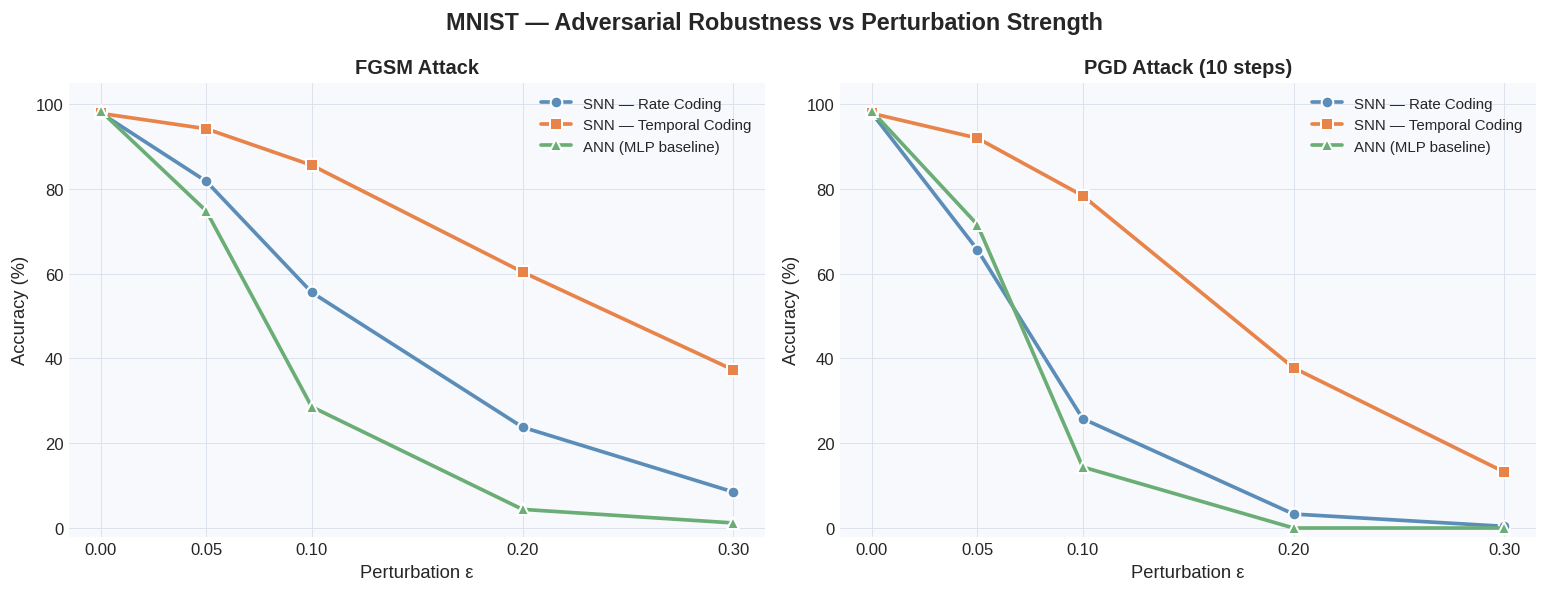

Fig 4 saved.


In [70]:
# ── Figure 4: Robustness curves — MNIST ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
fig.suptitle('MNIST — Adversarial Robustness vs Perturbation Strength',
             fontsize=14, fontweight='bold')

models_m = [
    ('snn_rate',      'SNN — Rate Coding',      PALETTE['snn_rate'],     'o-'),
    ('snn_temporal',  'SNN — Temporal Coding',  PALETTE['snn_temporal'], 's-'),
    ('ann',           'ANN (MLP baseline)',      PALETTE['ann'],          '^-'),
]

for ax, attack_key, title in [
    (axes[0], 'fgsm', 'FGSM Attack'),
    (axes[1], 'pgd',  'PGD Attack (10 steps)'),
]:
    for key, lbl, col, mark in models_m:
        ax.plot(EPS_MNIST, res_m[key][attack_key], mark, color=col,
                lw=2.2, markersize=7, markeredgewidth=1.2, markeredgecolor='white', label=lbl)
    ax.set_xlabel('Perturbation ε', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(-2, 105)
    ax.legend(loc='upper right')
    ax.set_xticks(EPS_MNIST)

plt.tight_layout()
plt.savefig('figures/fig04_mnist_robustness.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 4 saved.')

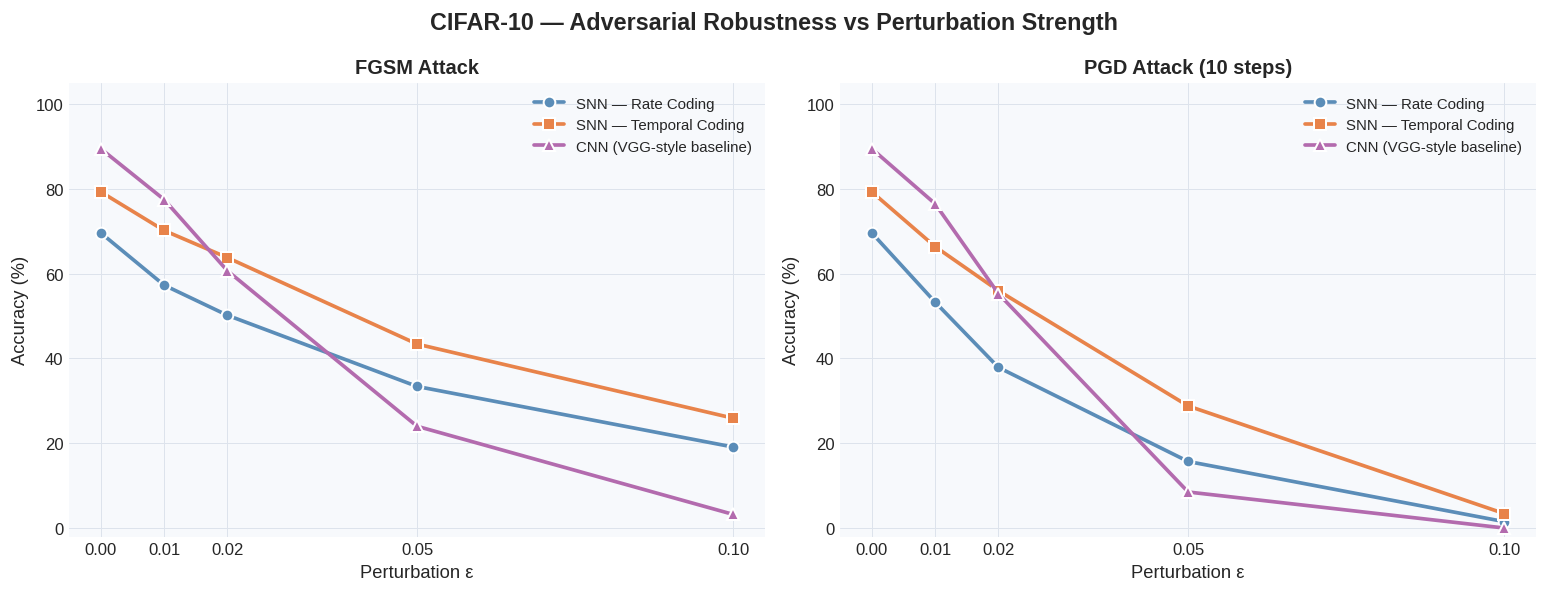

Fig 5 saved.


In [71]:
# ── Figure 5: Robustness curves — CIFAR-10 ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
fig.suptitle('CIFAR-10 — Adversarial Robustness vs Perturbation Strength',
             fontsize=14, fontweight='bold')

models_c = [
    ('snn_rate',      'SNN — Rate Coding',      PALETTE['snn_rate'],     'o-'),
    ('snn_temporal',  'SNN — Temporal Coding',  PALETTE['snn_temporal'], 's-'),
    ('cnn',           'CNN (VGG-style baseline)',PALETTE['cnn'],          '^-'),
]

for ax, attack_key, title in [
    (axes[0], 'fgsm', 'FGSM Attack'),
    (axes[1], 'pgd',  'PGD Attack (10 steps)'),
]:
    for key, lbl, col, mark in models_c:
        ax.plot(EPS_CIFAR, res_c[key][attack_key], mark, color=col,
                lw=2.2, markersize=7, markeredgewidth=1.2, markeredgecolor='white', label=lbl)
    ax.set_xlabel('Perturbation ε', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(-2, 105)
    ax.legend(loc='upper right')
    ax.set_xticks(EPS_CIFAR)

plt.tight_layout()
plt.savefig('figures/fig05_cifar_robustness.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 5 saved.')

## 9 · Summary Results Tables (poster-ready)

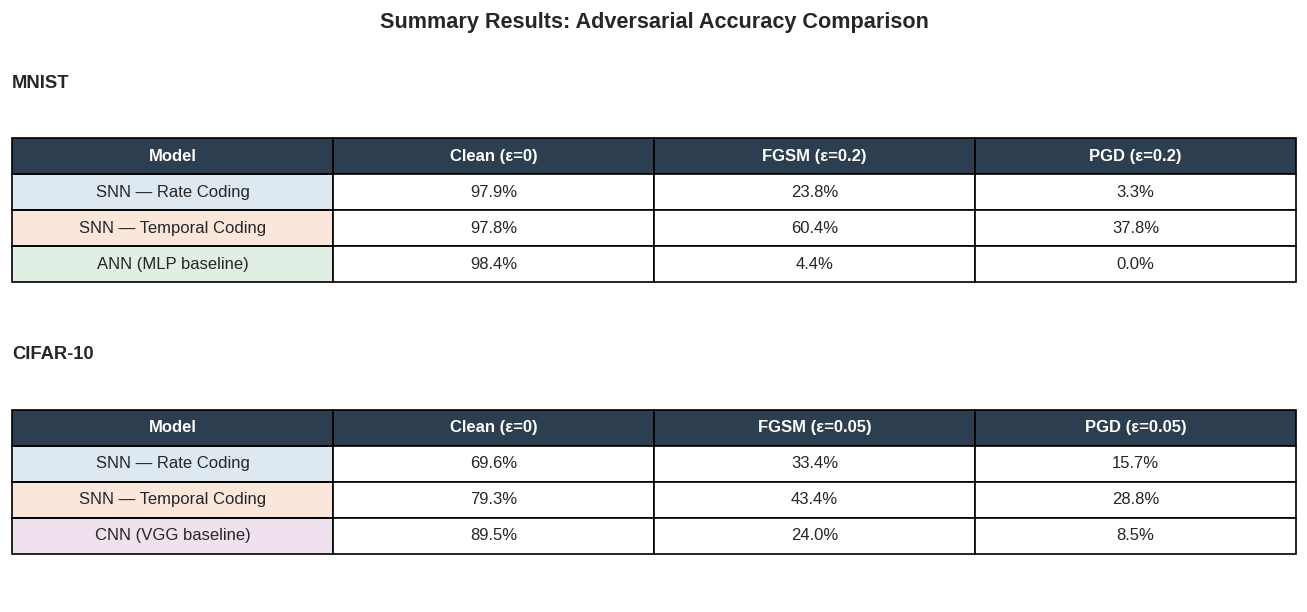

Fig 6 saved.


In [72]:
# ── Figure 6: Combined results table — MNIST ──────────────────────────────────
# Pick a single representative epsilon for the table (the poster epsilon)
EPS_M_TABLE = 0.2   # moderate attack
EPS_C_TABLE = 0.05

idx_m = EPS_MNIST.index(EPS_M_TABLE)
idx_c = EPS_CIFAR.index(EPS_C_TABLE)

table_data_m = [
    ['SNN — Rate Coding',     f"{res_m['snn_rate']['fgsm'][0]:.1f}%",
                               f"{res_m['snn_rate']['fgsm'][idx_m]:.1f}%",
                               f"{res_m['snn_rate']['pgd'][idx_m]:.1f}%"],
    ['SNN — Temporal Coding', f"{res_m['snn_temporal']['fgsm'][0]:.1f}%",
                               f"{res_m['snn_temporal']['fgsm'][idx_m]:.1f}%",
                               f"{res_m['snn_temporal']['pgd'][idx_m]:.1f}%"],
    ['ANN (MLP baseline)',    f"{res_m['ann']['fgsm'][0]:.1f}%",
                               f"{res_m['ann']['fgsm'][idx_m]:.1f}%",
                               f"{res_m['ann']['pgd'][idx_m]:.1f}%"],
]

table_data_c = [
    ['SNN — Rate Coding',     f"{res_c['snn_rate']['fgsm'][0]:.1f}%",
                               f"{res_c['snn_rate']['fgsm'][idx_c]:.1f}%",
                               f"{res_c['snn_rate']['pgd'][idx_c]:.1f}%"],
    ['SNN — Temporal Coding', f"{res_c['snn_temporal']['fgsm'][0]:.1f}%",
                               f"{res_c['snn_temporal']['fgsm'][idx_c]:.1f}%",
                               f"{res_c['snn_temporal']['pgd'][idx_c]:.1f}%"],
    ['CNN (VGG baseline)',    f"{res_c['cnn']['fgsm'][0]:.1f}%",
                               f"{res_c['cnn']['fgsm'][idx_c]:.1f}%",
                               f"{res_c['cnn']['pgd'][idx_c]:.1f}%"],
]

col_labels = ['Model', f'Clean (ε=0)', f'FGSM (ε={EPS_M_TABLE})', f'PGD (ε={EPS_M_TABLE})']
col_labels_c = ['Model', 'Clean (ε=0)', f'FGSM (ε={EPS_C_TABLE})', f'PGD (ε={EPS_C_TABLE})']

CELL_COLORS = ['#EEF3FB', '#E8F5E9', '#FFF3E0', '#FDECEA']  # header + 3 rows

fig, axes = plt.subplots(2, 1, figsize=(11, 5))
fig.suptitle('Summary Results: Adversarial Accuracy Comparison',
             fontsize=13, fontweight='bold', y=1.01)

for ax, data, cols, title, row_colors in [
    (axes[0], table_data_m, col_labels,   'MNIST',
     [[PALETTE['snn_rate']+'33', 'white', 'white', 'white'],
      [PALETTE['snn_temporal']+'33', 'white', 'white', 'white'],
      [PALETTE['ann']+'33', 'white', 'white', 'white']]),
    (axes[1], table_data_c, col_labels_c, 'CIFAR-10',
     [[PALETTE['snn_rate']+'33', 'white', 'white', 'white'],
      [PALETTE['snn_temporal']+'33', 'white', 'white', 'white'],
      [PALETTE['cnn']+'33', 'white', 'white', 'white']]),
]:
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left', pad=2)
    t = ax.table(
        cellText=data,
        colLabels=cols,
        cellLoc='center',
        loc='center',
        cellColours=row_colors,
    )
    t.auto_set_font_size(False)
    t.set_fontsize(10)
    t.scale(1, 1.6)
    # Style header
    for j in range(len(cols)):
        t[0, j].set_facecolor('#2C3E50')
        t[0, j].set_text_props(color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig06_results_tables.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 6 saved.')

## 10 · Figure 7 — Grouped Bar Chart (Poster Hero Figure)

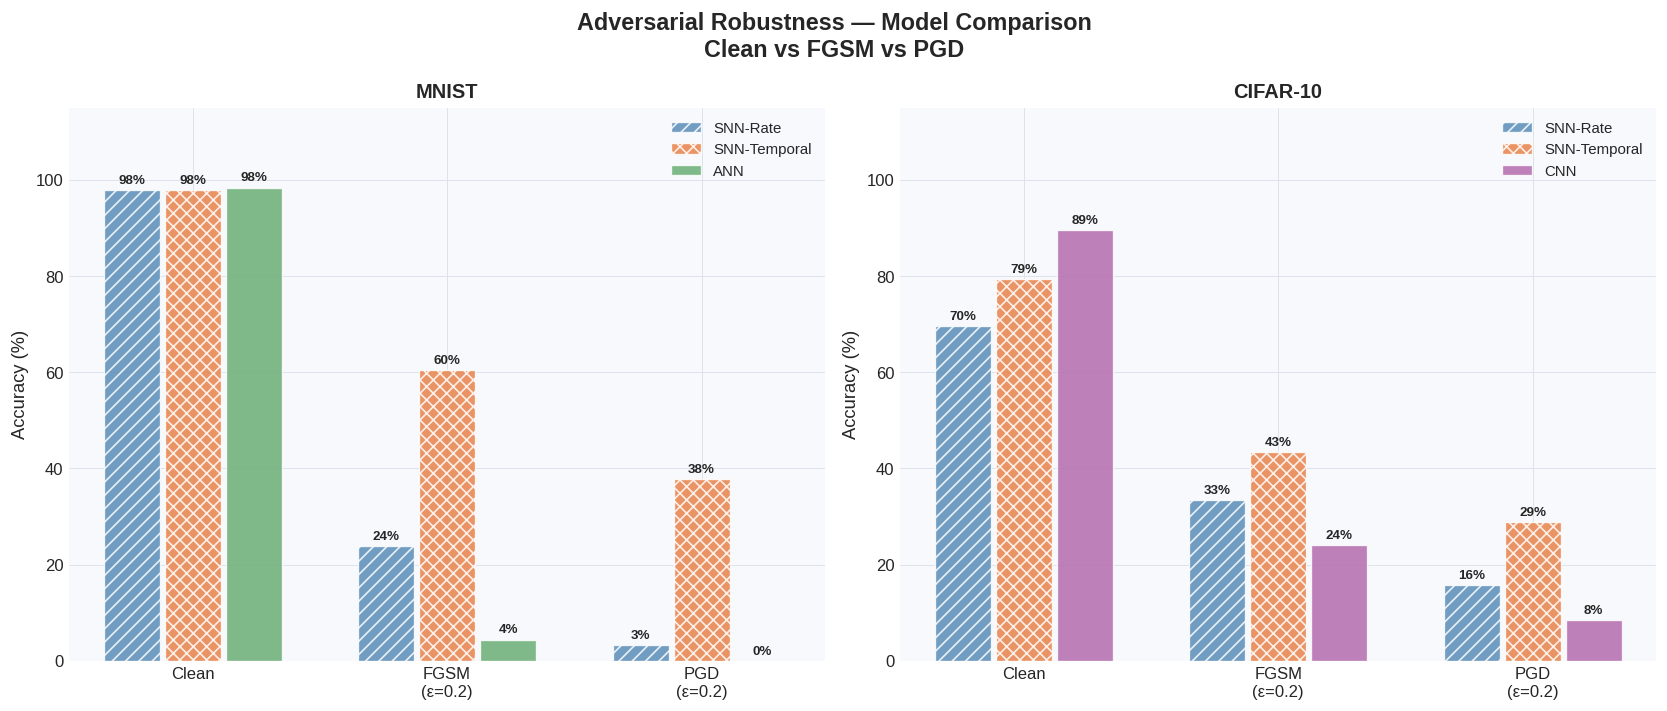

Fig 7 saved.


In [73]:
# ── Figure 7: Grouped bar — side-by-side dataset panels, 3 conditions ─────────
conditions = ['Clean', f'FGSM\n(ε={EPS_M_TABLE})', f'PGD\n(ε={EPS_M_TABLE})']

def get_bars(results, eps_list, eps_table, keys):
    idx = eps_list.index(eps_table)
    data = {}
    for k in keys:
        clean = results[k]['fgsm'][0]
        fgsm  = results[k]['fgsm'][idx]
        pgd   = results[k]['pgd'][idx]
        data[k] = [clean, fgsm, pgd]
    return data

bars_m = get_bars(res_m, EPS_MNIST, EPS_M_TABLE, ['snn_rate', 'snn_temporal', 'ann'])
bars_c = get_bars(res_c, EPS_CIFAR, EPS_C_TABLE, ['snn_rate', 'snn_temporal', 'cnn'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Adversarial Robustness — Model Comparison\nClean vs FGSM vs PGD',
             fontsize=14, fontweight='bold')

model_labels = [
    ('snn_rate',     'SNN-Rate',     PALETTE['snn_rate'],     '///'),
    ('snn_temporal', 'SNN-Temporal', PALETTE['snn_temporal'], 'xxx'),
    ('ann',          'ANN',          PALETTE['ann'],          ''),
]
model_labels_c = [
    ('snn_rate',     'SNN-Rate',     PALETTE['snn_rate'],     '///'),
    ('snn_temporal', 'SNN-Temporal', PALETTE['snn_temporal'], 'xxx'),
    ('cnn',          'CNN',          PALETTE['cnn'],          ''),
]

x = np.arange(len(conditions))
w = 0.22

for ax, bars, mlabels, title, ep_label in [
    (axes[0], bars_m, model_labels,   'MNIST',     EPS_M_TABLE),
    (axes[1], bars_c, model_labels_c, 'CIFAR-10',  EPS_C_TABLE),
]:
    for i, (key, lbl, col, hatch) in enumerate(mlabels):
        offset = (i - 1) * (w + 0.02)
        vals = bars[key]
        bars_plot = ax.bar(x + offset, vals, w,
                           label=lbl, color=col, alpha=0.85,
                           hatch=hatch, edgecolor='white', linewidth=0.8)
        for bar, v in zip(bars_plot, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                    f'{v:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(conditions, fontsize=10)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 115)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('figures/fig07_grouped_bar.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 7 saved.')

## 11 · Figure 8 — Accuracy Drop Heatmap

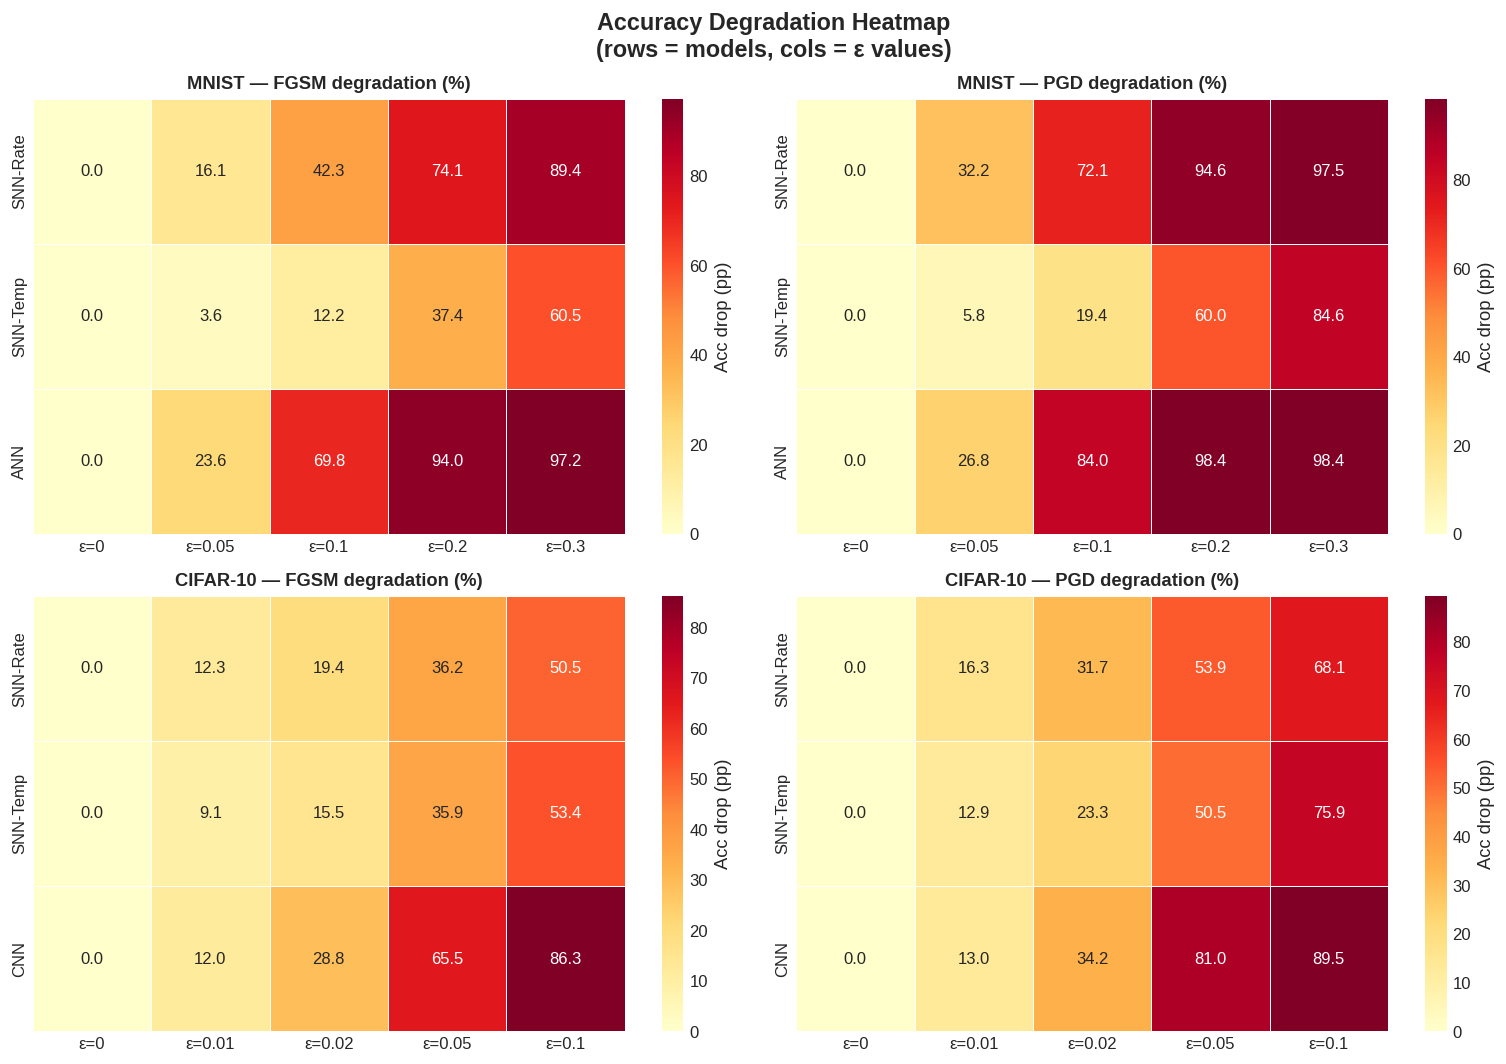

Fig 8 saved.


In [74]:
# ── Figure 8: Accuracy-drop heatmap across all epsilon ────────────────────────
# Shows degradation (clean acc - attacked acc) as heat

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Accuracy Degradation Heatmap\n(rows = models, cols = ε values)',
             fontsize=14, fontweight='bold')

def make_drop_matrix(results, eps_list, model_keys, model_names, attack_key):
    clean_idx = 0
    matrix = []
    for k in model_keys:
        clean = results[k][attack_key][clean_idx]
        row = [clean - results[k][attack_key][i] for i in range(len(eps_list))]
        matrix.append(row)
    return np.array(matrix)

configs = [
    (axes[0,0], res_m, EPS_MNIST,  ['snn_rate','snn_temporal','ann'],
     ['SNN-Rate','SNN-Temp','ANN'], 'fgsm', 'MNIST — FGSM degradation (%)'),
    (axes[0,1], res_m, EPS_MNIST,  ['snn_rate','snn_temporal','ann'],
     ['SNN-Rate','SNN-Temp','ANN'], 'pgd',  'MNIST — PGD degradation (%)'),
    (axes[1,0], res_c, EPS_CIFAR,  ['snn_rate','snn_temporal','cnn'],
     ['SNN-Rate','SNN-Temp','CNN'], 'fgsm', 'CIFAR-10 — FGSM degradation (%)'),
    (axes[1,1], res_c, EPS_CIFAR,  ['snn_rate','snn_temporal','cnn'],
     ['SNN-Rate','SNN-Temp','CNN'], 'pgd',  'CIFAR-10 — PGD degradation (%)'),
]

for ax, results, eps_list, mkeys, mnames, atk, title in configs:
    mat = make_drop_matrix(results, eps_list, mkeys, mnames, atk)
    sns.heatmap(mat, ax=ax,
                xticklabels=[f'ε={e}' for e in eps_list],
                yticklabels=mnames,
                annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Acc drop (pp)'})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('figures/fig08_degradation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 8 saved.')

## 12 · Figure 9 — Adversarial Sample Visualisation (MNIST)

In [75]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# ── 1. Define the Aesthetic theme (Fixes the KeyError) ──
PALETTE = {
    'snn_rate'     : '#5B8DB8',
    'snn_temporal' : '#E8834A',
    'ann'          : '#6BAE75',
    'cnn'          : '#B36BAE',
    'fgsm'         : '#E8834A',
    'pgd'          : '#C0392B',
    'clean'        : '#2ECC71',
    'bg'           : '#F7F9FC',
    'grid'         : '#DDE3EC',
}

# ── 2. Define Encoding Functions (Required for predictions) ──
def rate_encode(x, num_steps):
    """Rate coding: pixel value sets spike probability."""
    x_exp = x.unsqueeze(0).expand(num_steps, *x.shape)
    return torch.bernoulli(x_exp)

def temporal_encode(x, num_steps):
    """Temporal coding: pixel value sets spike latency."""
    T = num_steps
    spikes = torch.zeros(T, *x.shape, device=x.device)
    spike_times = ((1.0 - x.clamp(0, 1)) * (T - 1)).round().long().clamp(0, T - 1)
    for t in range(T):
        spikes[t] = (spike_times == t).float()
    return spikes

# ── 3. Basic Plotting Config ──
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : PALETTE['bg'],
    'axes.grid'         : True,
    'grid.color'        : PALETTE['grid'],
})

print("Setup complete: PALETTE and Encoders defined.")

Setup complete: PALETTE and Encoders defined.


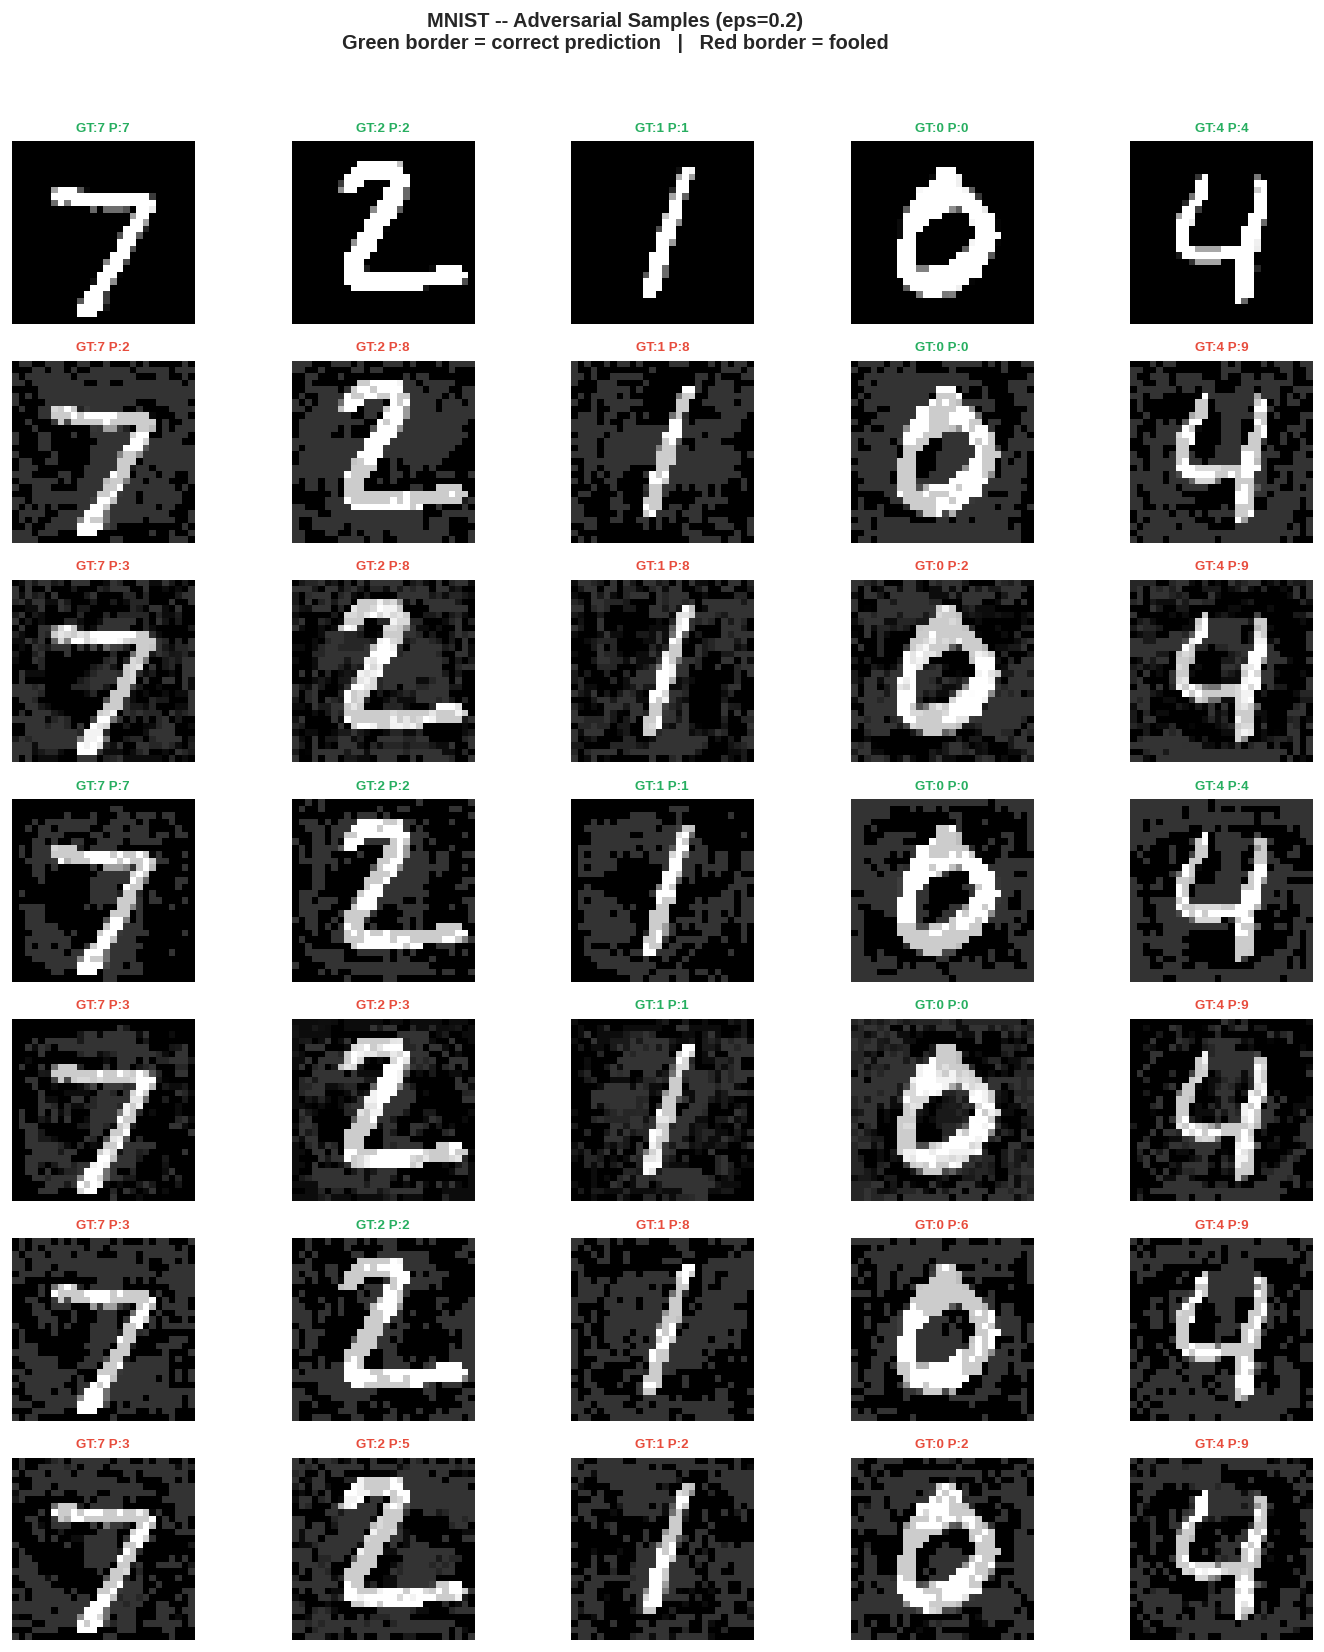

Fig 9 saved.


In [83]:
# == Figure 9: MNIST -- Clean vs Adversarial image grid ======================
# 7 rows: Original | SNN-Rate FGSM | SNN-Rate PGD |
#         SNN-Temporal FGSM | SNN-Temporal PGD | ANN FGSM | ANN PGD
# N_SHOW cols, green/red border = correct/fooled

N_SHOW    = 5
EPS_VIZ_M = 0.2

viz_loader = DataLoader(torch.utils.data.Subset(mnist_test, range(64)), batch_size=64)
imgs_v, labels_v = next(iter(viz_loader))
imgs_v, labels_v = imgs_v.to(device), labels_v.to(device)

model_sr.eval(); model_st.eval(); model_ann.eval()

# Generate adversarial examples for all 3 models
adv_fgsm_sr  = fgsm_attack_snn(model_sr,  imgs_v, labels_v, EPS_VIZ_M, SNN_STEPS, 'rate')
adv_pgd_sr   = pgd_attack_snn( model_sr,  imgs_v, labels_v, EPS_VIZ_M, 10, None, SNN_STEPS, 'rate')
adv_fgsm_st  = fgsm_attack_snn(model_st,  imgs_v, labels_v, EPS_VIZ_M, SNN_STEPS, 'temporal')
adv_pgd_st   = pgd_attack_snn( model_st,  imgs_v, labels_v, EPS_VIZ_M, 10, None, SNN_STEPS, 'temporal')
adv_fgsm_ann = fgsm_attack_ann(model_ann, imgs_v, labels_v, EPS_VIZ_M)
adv_pgd_ann  = pgd_attack_ann( model_ann, imgs_v, labels_v, EPS_VIZ_M, 10)

with torch.no_grad():
    pred_clean_sr  = model_sr(rate_encode(imgs_v,       SNN_STEPS)).argmax(1)
    pred_fgsm_sr   = model_sr(rate_encode(adv_fgsm_sr,  SNN_STEPS)).argmax(1)
    pred_pgd_sr    = model_sr(rate_encode(adv_pgd_sr,   SNN_STEPS)).argmax(1)
    pred_clean_st  = model_st(temporal_encode(imgs_v,   SNN_STEPS)).argmax(1)
    pred_fgsm_st   = model_st(temporal_encode(adv_fgsm_st, SNN_STEPS)).argmax(1)
    pred_pgd_st    = model_st(temporal_encode(adv_pgd_st,  SNN_STEPS)).argmax(1)
    pred_clean_ann = model_ann(imgs_v).argmax(1)
    pred_fgsm_ann  = model_ann(adv_fgsm_ann).argmax(1)
    pred_pgd_ann   = model_ann(adv_pgd_ann).argmax(1)

# 7 rows: (image_tensor, preds, row_label, row_color)
row_imgs = [
    (imgs_v,       pred_clean_sr,  'Original',          '#2C3E50'),
    (adv_fgsm_sr,  pred_fgsm_sr,   'SNN-Rate\nFGSM',    PALETTE['snn_rate']),
    (adv_pgd_sr,   pred_pgd_sr,    'SNN-Rate\nPGD',     PALETTE['pgd']),
    (adv_fgsm_st,  pred_fgsm_st,   'SNN-Temp\nFGSM',   PALETTE['snn_temporal']),
    (adv_pgd_st,   pred_pgd_st,    'SNN-Temp\nPGD',    PALETTE['pgd']),
    (adv_fgsm_ann, pred_fgsm_ann,  'ANN\nFGSM',        PALETTE['ann']),
    (adv_pgd_ann,  pred_pgd_ann,   'ANN\nPGD',         PALETTE['ann']),
]

fig, axes = plt.subplots(7, N_SHOW, figsize=(13, 14))
fig.suptitle(
    f'MNIST -- Adversarial Samples (eps={EPS_VIZ_M})\n'
    'Green border = correct prediction   |   Red border = fooled',
    fontsize=12, fontweight='bold'
)

for row, (img_tensor, preds, row_label, row_color) in enumerate(row_imgs):
    axes[row, 0].set_ylabel(row_label, fontsize=9, fontweight='bold',
                             color=row_color, rotation=90, labelpad=6,
                             va='center')
    for col in range(N_SHOW):
        ax = axes[row, col]
        img = img_tensor[col].cpu().squeeze().numpy()
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        gt = labels_v[col].item()
        pr = preds[col].item()
        correct = (pr == gt)
        color = '#27AE60' if correct else '#E74C3C'
        ax.set_title(f'GT:{gt} P:{pr}', fontsize=8, color=color, fontweight='bold')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2.5)
        ax.set(xticks=[], yticks=[])

plt.tight_layout(rect=[0.06, 0, 1, 0.96])
plt.savefig('figures/fig09_mnist_adv_samples.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 9 saved.')


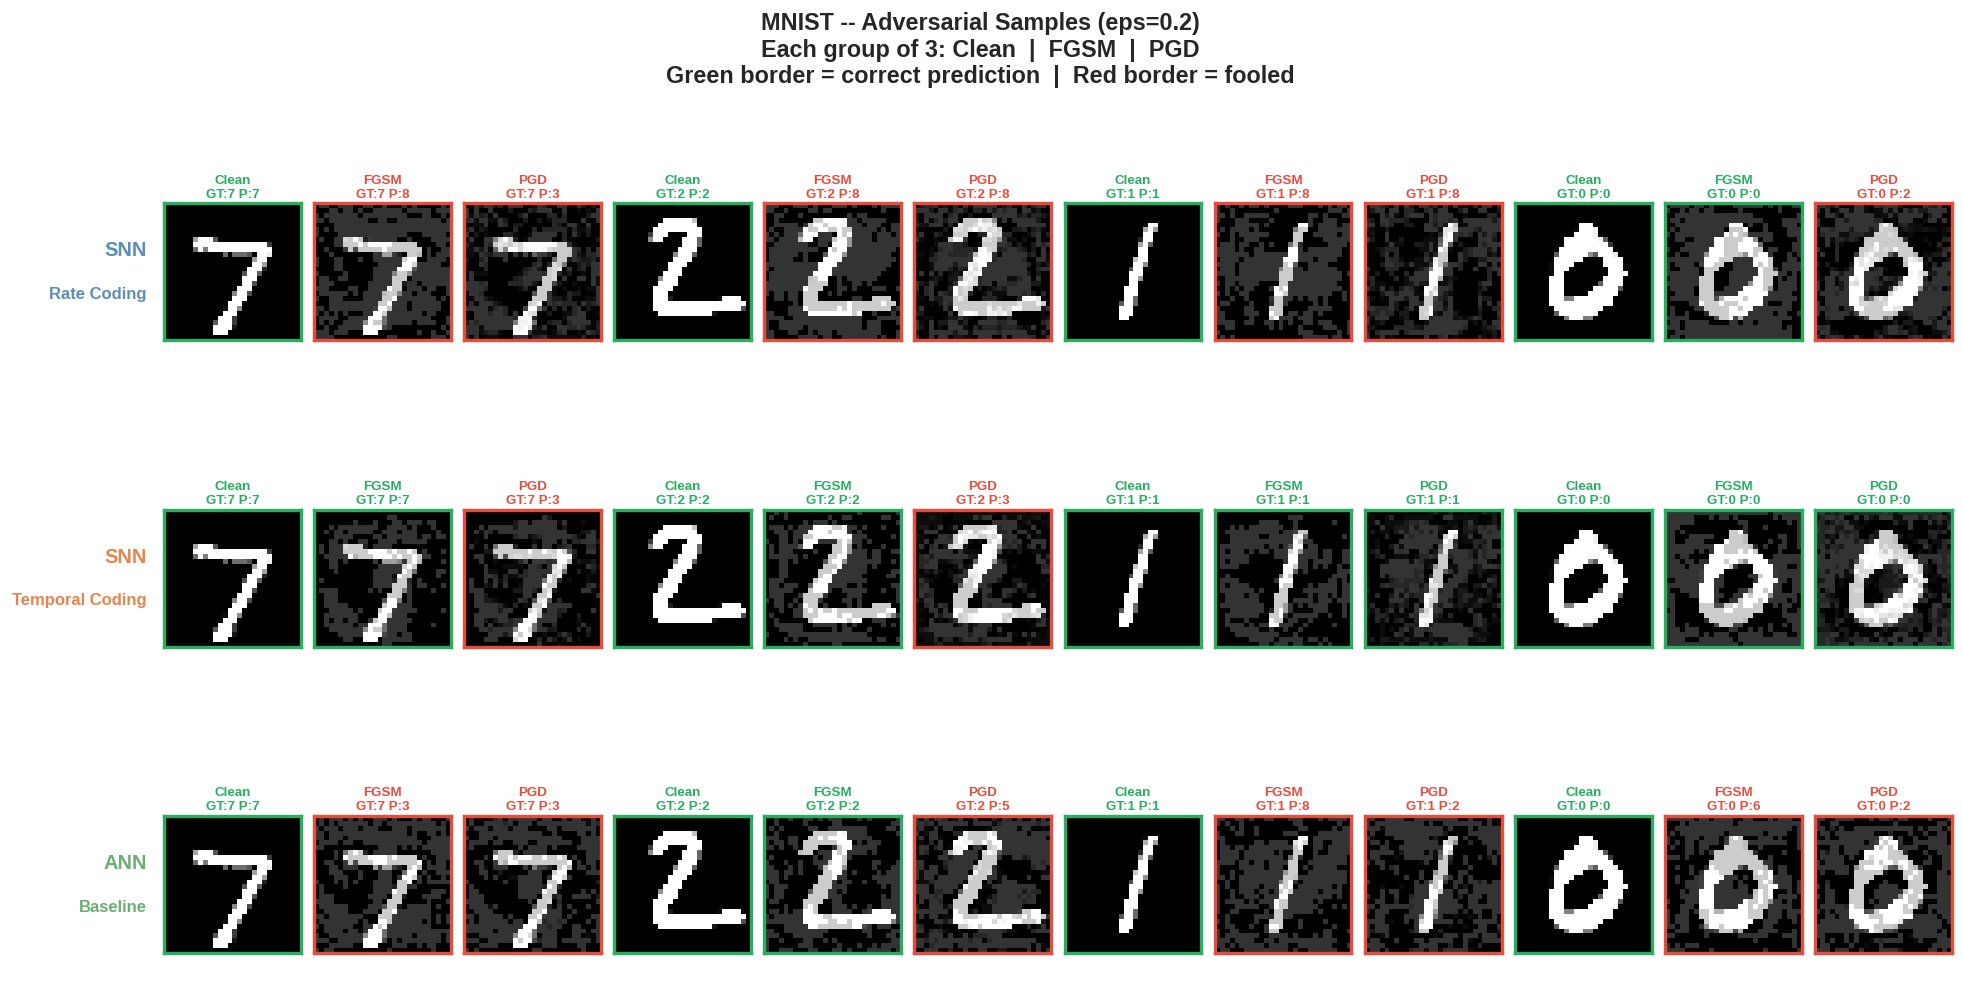

Fig 9 v2 saved.


In [88]:
import matplotlib.gridspec as gridspec

# == Figure 9: MNIST -- Clean vs Adversarial image grid (Updated) ============
N_SHOW    = 4  # Number of different digits to show
EPS_VIZ_M = 0.2

# We will show 3 variants for each sample: Clean, FGSM, PGD
# Total image columns = N_SHOW * 3
n_cols_imgs = N_SHOW * 3
n_rows = 3 # SNN-Rate, SNN-Temporal, ANN

fig = plt.figure(figsize=((n_cols_imgs + 1.5) * 1.5, n_rows * 3.0))
fig.suptitle(
    f'MNIST -- Adversarial Samples (eps={EPS_VIZ_M})\n'
    'Each group of 3: Clean  |  FGSM  |  PGD\n'
    'Green border = correct prediction  |  Red border = fooled',
    fontsize=14, fontweight='bold', y=1.02
)

# Build gridspec: 1 label col + image cols
gs = gridspec.GridSpec(n_rows, n_cols_imgs + 1,
                       width_ratios=[0.6] + [1]*n_cols_imgs,
                       wspace=0.1, hspace=0.4)

# Define rows and their respective models/attacks
# (Label1, Label2, model, adv_fgsm, adv_pgd, encoding_fn, color)
row_configs = [
    ('SNN', 'Rate Coding', model_sr, adv_fgsm_sr, adv_pgd_sr, 
     lambda x: rate_encode(x, SNN_STEPS), PALETTE['snn_rate']),
    ('SNN', 'Temporal Coding', model_st, adv_fgsm_st, adv_pgd_st, 
     lambda x: temporal_encode(x, SNN_STEPS), PALETTE['snn_temporal']),
    ('ANN', 'Baseline', model_ann, adv_fgsm_ann, adv_pgd_ann, 
     lambda x: x, PALETTE['ann']),
]

for row_i, (lbl1, lbl2, model, adv_f, adv_p, enc_fn, lbl_color) in enumerate(row_configs):
    
    # 1. Row Label (Left Column)
    ax_lbl = fig.add_subplot(gs[row_i, 0])
    ax_lbl.axis('off')
    ax_lbl.text(0.95, 0.6, lbl1, ha='right', va='center', 
                fontsize=12, fontweight='bold', color=lbl_color, transform=ax_lbl.transAxes)
    ax_lbl.text(0.95, 0.4, lbl2, ha='right', va='center', 
                fontsize=10, fontweight='bold', color=lbl_color, transform=ax_lbl.transAxes)

    for col_i in range(N_SHOW):
        gt = labels_v[col_i].item()
        
        # Sub-group: Clean, FGSM, PGD
        for j, (img_tensor, col_lbl) in enumerate([
            (imgs_v,   'Clean'),
            (adv_f,    'FGSM'),
            (adv_p,    'PGD'),
        ]):
            ax = fig.add_subplot(gs[row_i, 1 + col_i * 3 + j])
            
            # Prepare image
            img = img_tensor[col_i].cpu().squeeze().numpy()
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            
            # Prediction
            with torch.no_grad():
                pred = model(enc_fn(img_tensor[col_i].unsqueeze(0).to(device))).argmax(1).item()
            
            correct = (pred == gt)
            border_color = '#27AE60' if correct else '#E74C3C'
            
            # Title for each small image
            ax.set_title(f'{col_lbl}\nGT:{gt} P:{pred}', 
                         fontsize=8, color=border_color, fontweight='bold', pad=4)
            
            # Add colored border for visual feedback
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor(border_color)
                spine.set_linewidth(2)
            
            ax.set_xticks([]); ax.set_yticks([])

plt.savefig('figures/fig09_mnist_adv_samples_v2.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 9 v2 saved.')

## 13 · Figure 10 — Adversarial Sample Visualisation (CIFAR-10)

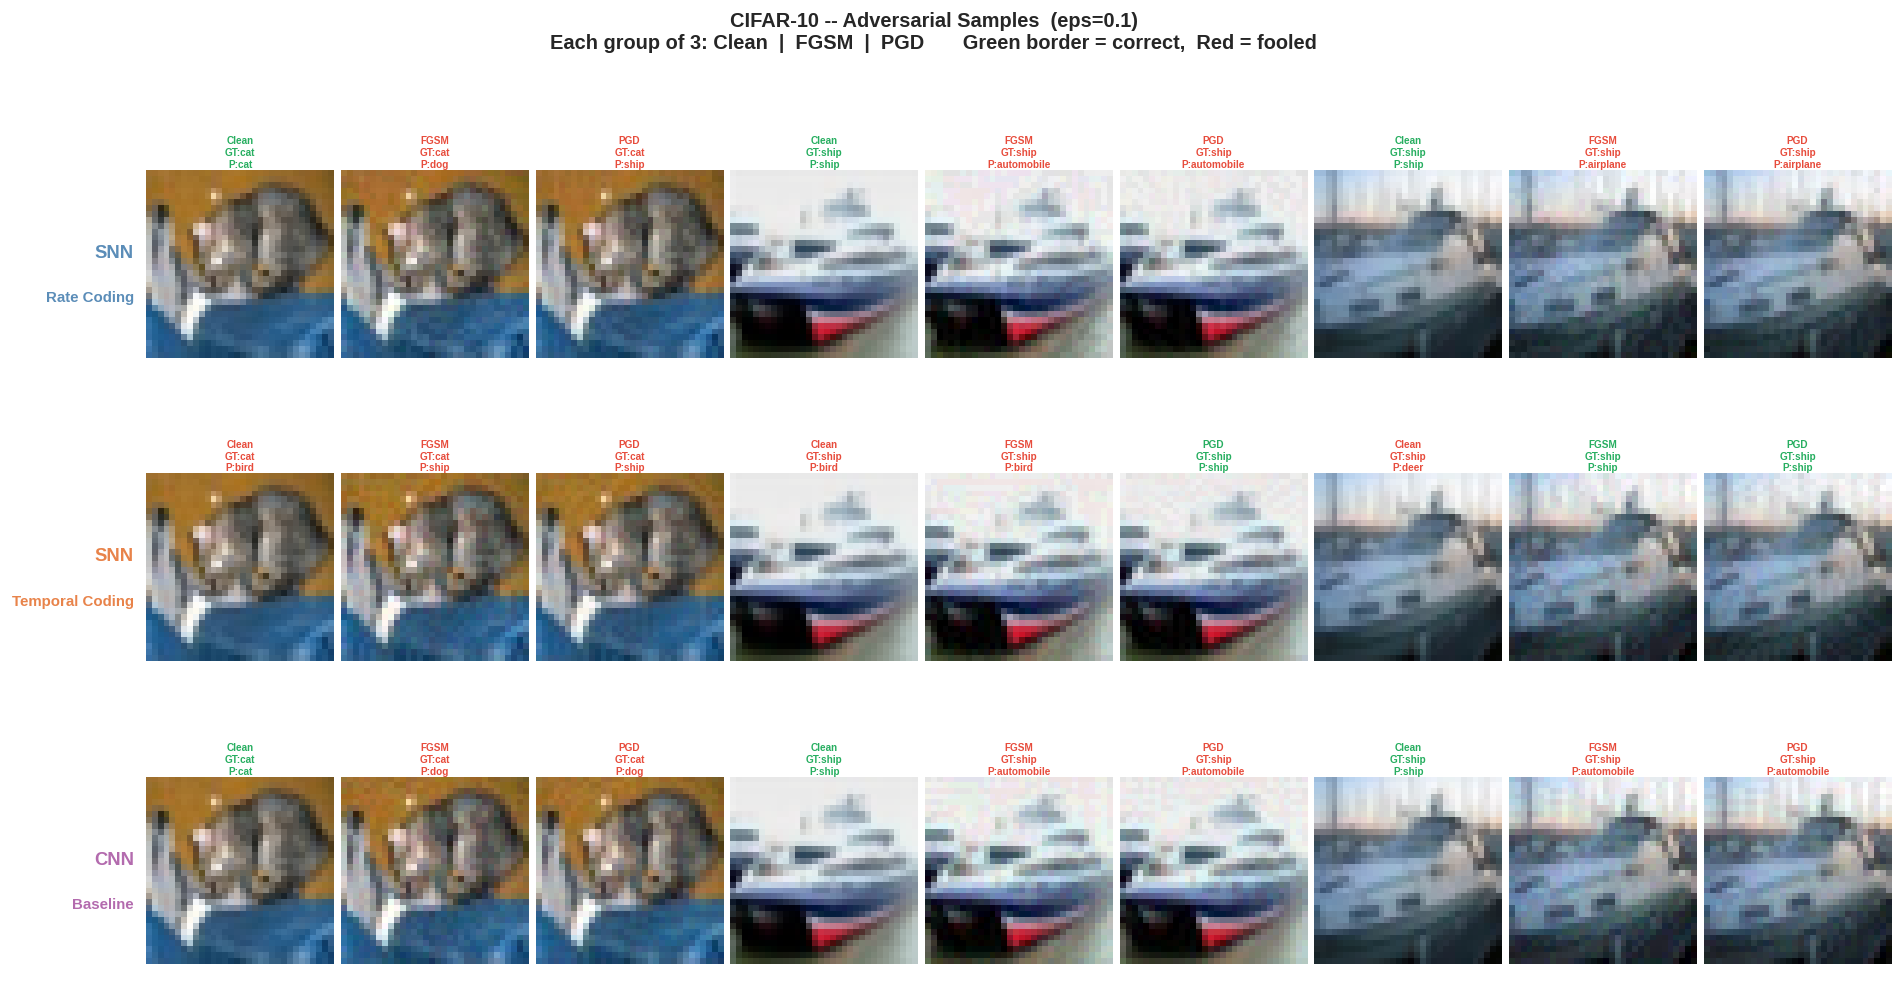

Figure 10 saved.


In [84]:
# == Figure 10: CIFAR-10 adversarial samples =================================
# 3 rows (SNN-Rate / SNN-Temporal / CNN) x N_SHOW_C*3 cols (clean/FGSM/PGD)
# Row labels on the left use model color so poster readers can read without legend

N_SHOW_C  = 3
EPS_VIZ_C = 0.1

CIFAR_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

viz_loader_c = DataLoader(torch.utils.data.Subset(cifar_test, range(64)),
                           batch_size=64, num_workers=0)
imgs_vc, labels_vc = next(iter(viz_loader_c))
imgs_vc, labels_vc = imgs_vc.to(device), labels_vc.to(device)

model_src.eval(); model_stc.eval(); model_cnn.eval()

# Rate model attacks (T=10)
adv_fgsm_src = fgsm_attack_snn(model_src, imgs_vc, labels_vc, EPS_VIZ_C,
                                C_RATE_STEPS, 'rate', True, clamp_cifar)
adv_pgd_src  = pgd_attack_snn(model_src, imgs_vc, labels_vc, EPS_VIZ_C, 10, None,
                               C_RATE_STEPS, 'rate', True, clamp_cifar)

# Temporal model attacks (T=25)
adv_fgsm_stc = fgsm_attack_snn(model_stc, imgs_vc, labels_vc, EPS_VIZ_C,
                                C_TEMP_STEPS, 'temporal', True, clamp_cifar)
adv_pgd_stc  = pgd_attack_snn(model_stc, imgs_vc, labels_vc, EPS_VIZ_C, 10, None,
                               C_TEMP_STEPS, 'temporal', True, clamp_cifar)

# CNN attacks
adv_fgsm_cnn = fgsm_attack_ann(model_cnn, imgs_vc, labels_vc, EPS_VIZ_C, clamp_cifar)
adv_pgd_cnn  = pgd_attack_ann(model_cnn,  imgs_vc, labels_vc, EPS_VIZ_C, 10, None, clamp_cifar)

# Per-model prediction helpers
def _pred_src(img_t):
    with torch.no_grad():
        sp = img_t.unsqueeze(0).repeat(C_RATE_STEPS, 1, 1, 1, 1)
        return model_src(sp).argmax(1).item()

def _pred_stc(img_t):
    with torch.no_grad():
        t01 = denorm_cifar(img_t.cpu().unsqueeze(0)).to(device)
        return model_stc(temporal_encode_cifar(t01, C_TEMP_STEPS)).argmax(1).item()

def _pred_cnn(img_t):
    with torch.no_grad():
        return model_cnn(img_t.unsqueeze(0)).argmax(1).item()

# row_info: (label_line1, label_line2, adv_fgsm, adv_pgd, pred_fn, label_color)
row_info = [
    ('SNN', 'Rate Coding',    adv_fgsm_src, adv_pgd_src, _pred_src, PALETTE['snn_rate']),
    ('SNN', 'Temporal Coding',adv_fgsm_stc, adv_pgd_stc, _pred_stc, PALETTE['snn_temporal']),
    ('CNN', 'Baseline',       adv_fgsm_cnn, adv_pgd_cnn, _pred_cnn, PALETTE['cnn']),
]

n_rows = len(row_info)
n_cols = N_SHOW_C * 3   # 3 images per sample (clean/FGSM/PGD)

# Extra left column for row label => total cols = n_cols + 1
fig = plt.figure(figsize=((n_cols + 1.5) * 1.9, n_rows * 3.0))
fig.suptitle(
    f'CIFAR-10 -- Adversarial Samples  (eps={EPS_VIZ_C})\n'
    'Each group of 3: Clean  |  FGSM  |  PGD       '
    'Green border = correct,  Red = fooled',
    fontsize=12, fontweight='bold', y=1.01
)

# Build gridspec: 1 narrow label col + n_cols image cols
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(n_rows, n_cols + 1,
                       width_ratios=[0.55] + [1]*n_cols,
                       wspace=0.04, hspace=0.35)

for row_i, (lbl1, lbl2, adv_f, adv_p, pred_fn, lbl_color) in enumerate(row_info):

    # Left label cell
    ax_lbl = fig.add_subplot(gs[row_i, 0])
    ax_lbl.axis('off')
    ax_lbl.text(0.95, 0.55, lbl1,
                ha='right', va='center', fontsize=11, fontweight='bold',
                color=lbl_color, transform=ax_lbl.transAxes)
    ax_lbl.text(0.95, 0.35, lbl2,
                ha='right', va='center', fontsize=9, fontweight='bold',
                color=lbl_color, transform=ax_lbl.transAxes)

    for col_i in range(N_SHOW_C):
        gt = labels_vc[col_i].item()
        for j, (img_tensor, col_lbl) in enumerate([
            (imgs_vc, 'Clean'),
            (adv_f,   'FGSM'),
            (adv_p,   'PGD'),
        ]):
            ax = fig.add_subplot(gs[row_i, 1 + col_i * 3 + j])
            img_cpu  = img_tensor[col_i].cpu()
            img_disp = denorm_cifar(img_cpu).permute(1, 2, 0).numpy().clip(0, 1)
            ax.imshow(img_disp)
            pred = pred_fn(img_tensor[col_i].to(device))
            correct = (pred == gt)
            border_color = '#27AE60' if correct else '#E74C3C'
            ax.set_title(
                f'{col_lbl}\nGT:{CIFAR_CLASSES[gt]}\nP:{CIFAR_CLASSES[pred]}',
                fontsize=6, color=border_color, fontweight='bold', pad=2
            )
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(2.5)
            ax.set(xticks=[], yticks=[])

plt.savefig('figures/fig10_cifar_adv_samples.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 10 saved.')


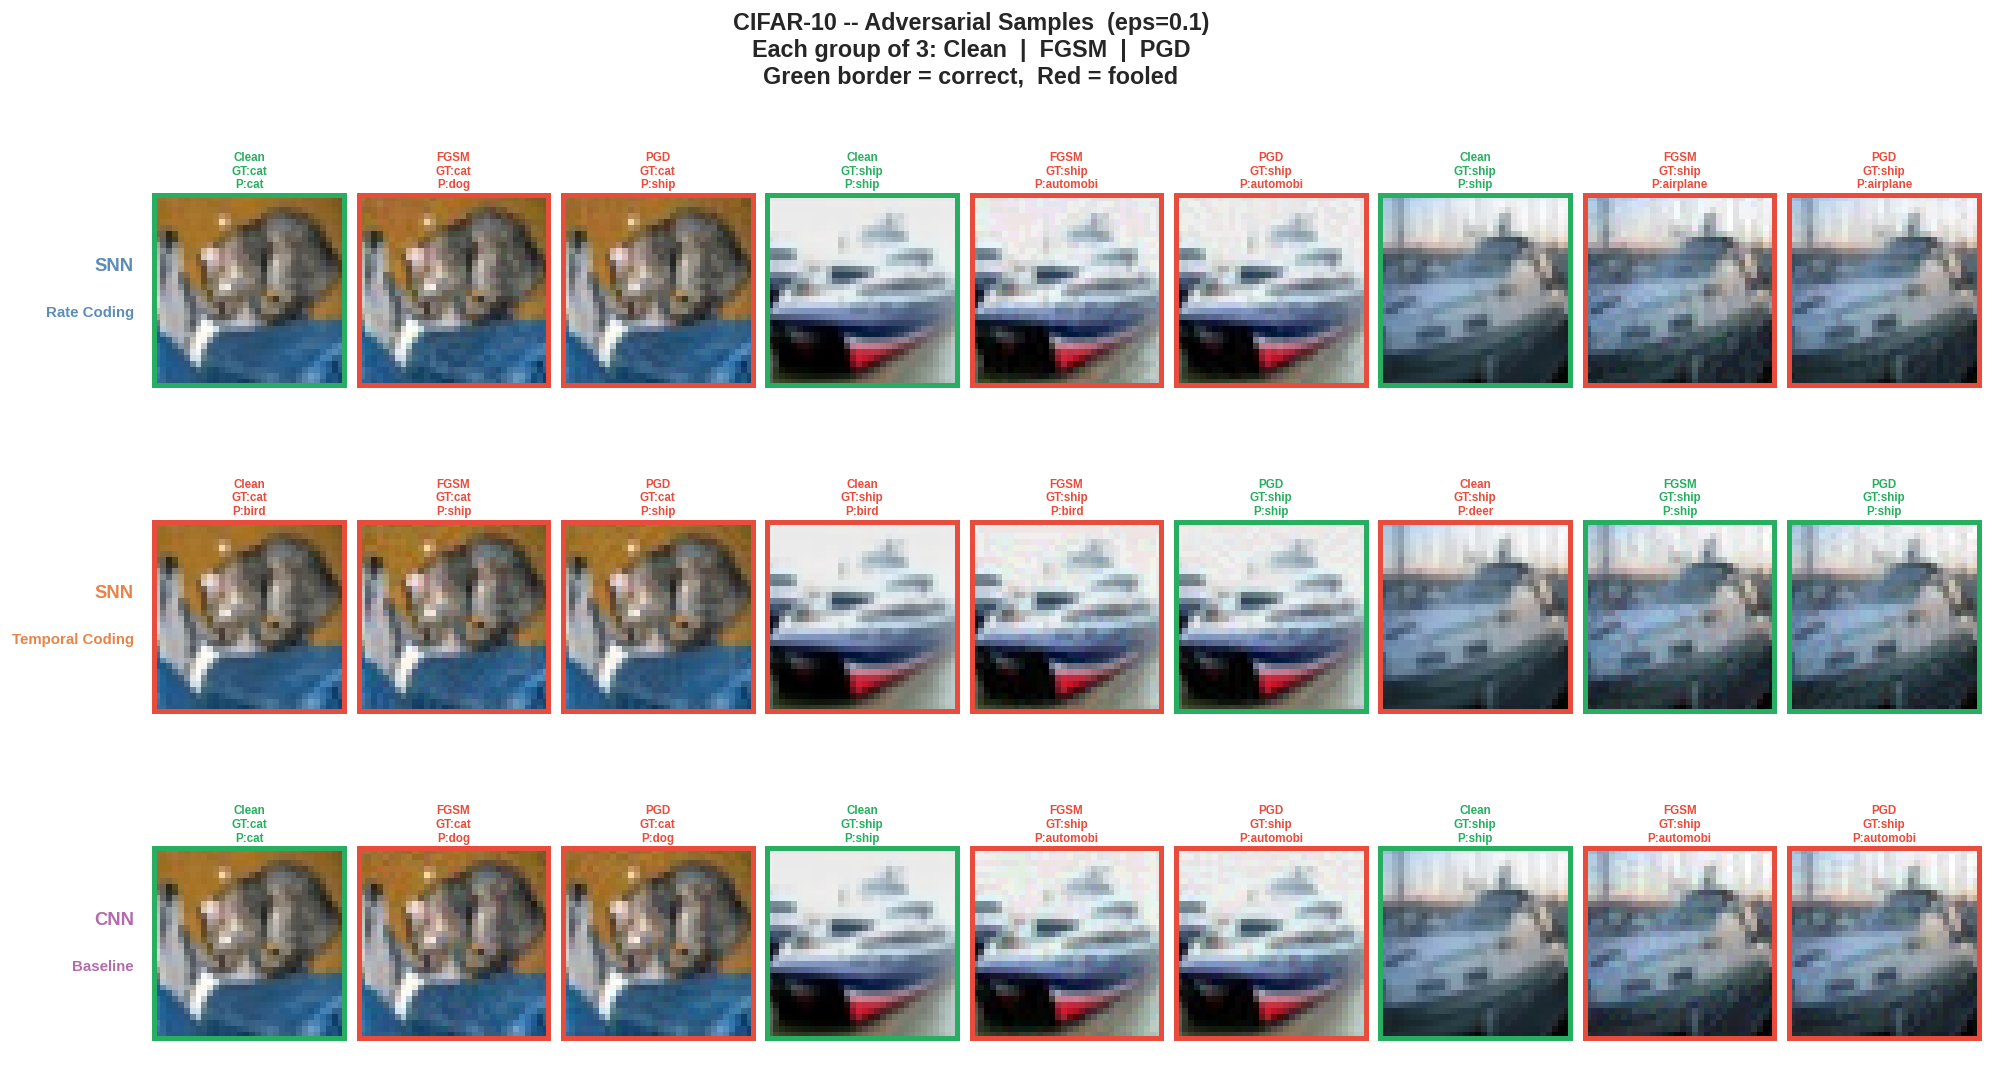

Figure 10 v2 saved.


In [89]:
import matplotlib.gridspec as gridspec

# == Figure 10: CIFAR-10 adversarial samples (Fixed Borders & Labels) ========
N_SHOW_C  = 3
EPS_VIZ_C = 0.1

# ... [Keep your attack generation code and _pred functions here] ...

n_rows = len(row_info)
n_cols = N_SHOW_C * 3  # 3 images per sample (clean/FGSM/PGD)

fig = plt.figure(figsize=((n_cols + 1.5) * 2.0, n_rows * 3.2))
fig.suptitle(
    f'CIFAR-10 -- Adversarial Samples  (eps={EPS_VIZ_C})\n'
    'Each group of 3: Clean  |  FGSM  |  PGD\n'
    'Green border = correct,  Red = fooled',
    fontsize=14, fontweight='bold', y=1.02
)

# Build gridspec: 1 narrow label col + n_cols image cols
gs = gridspec.GridSpec(n_rows, n_cols + 1,
                       width_ratios=[0.6] + [1]*n_cols,
                       wspace=0.08, hspace=0.4)

for row_i, (lbl1, lbl2, adv_f, adv_p, pred_fn, lbl_color) in enumerate(row_info):

    # Left label cell
    ax_lbl = fig.add_subplot(gs[row_i, 0])
    ax_lbl.axis('off')
    ax_lbl.text(0.95, 0.60, lbl1, ha='right', va='center', 
                fontsize=11, fontweight='bold', color=lbl_color, transform=ax_lbl.transAxes)
    ax_lbl.text(0.95, 0.40, lbl2, ha='right', va='center', 
                fontsize=9, fontweight='bold', color=lbl_color, transform=ax_lbl.transAxes)

    for col_i in range(N_SHOW_C):
        gt = labels_vc[col_i].item()
        
        for j, (img_tensor, col_lbl) in enumerate([
            (imgs_vc, 'Clean'),
            (adv_f,   'FGSM'),
            (adv_p,   'PGD'),
        ]):
            ax = fig.add_subplot(gs[row_i, 1 + col_i * 3 + j])
            
            # Prepare image
            img_cpu = img_tensor[col_i].cpu()
            img_disp = denorm_cifar(img_cpu).permute(1, 2, 0).numpy().clip(0, 1)
            ax.imshow(img_disp)
            
            # Get prediction and determine color
            pred = pred_fn(img_tensor[col_i].to(device))
            correct = (pred == gt)
            border_color = '#27AE60' if correct else '#E74C3C'
            
            # Title
            ax.set_title(
                f'{col_lbl}\nGT:{CIFAR_CLASSES[gt][:8]}\nP:{CIFAR_CLASSES[pred][:8]}',
                fontsize=7, color=border_color, fontweight='bold', pad=4
            )
            
            # MANDATORY: Explicitly turn on spines and set properties for the border
            for spine in ax.spines.values():
                spine.set_visible(True) # Ensure they aren't hidden by axis('off')
                spine.set_edgecolor(border_color)
                spine.set_linewidth(3.0) # Slightly thicker for visibility on color images
            
            # Remove ticks but keep the spines
            ax.set_xticks([])
            ax.set_yticks([])

plt.savefig('figures/fig10_cifar_adv_samples_fixed.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 10 v2 saved.')

## 14 · Figure 11 — Perturbation Noise Visualisation

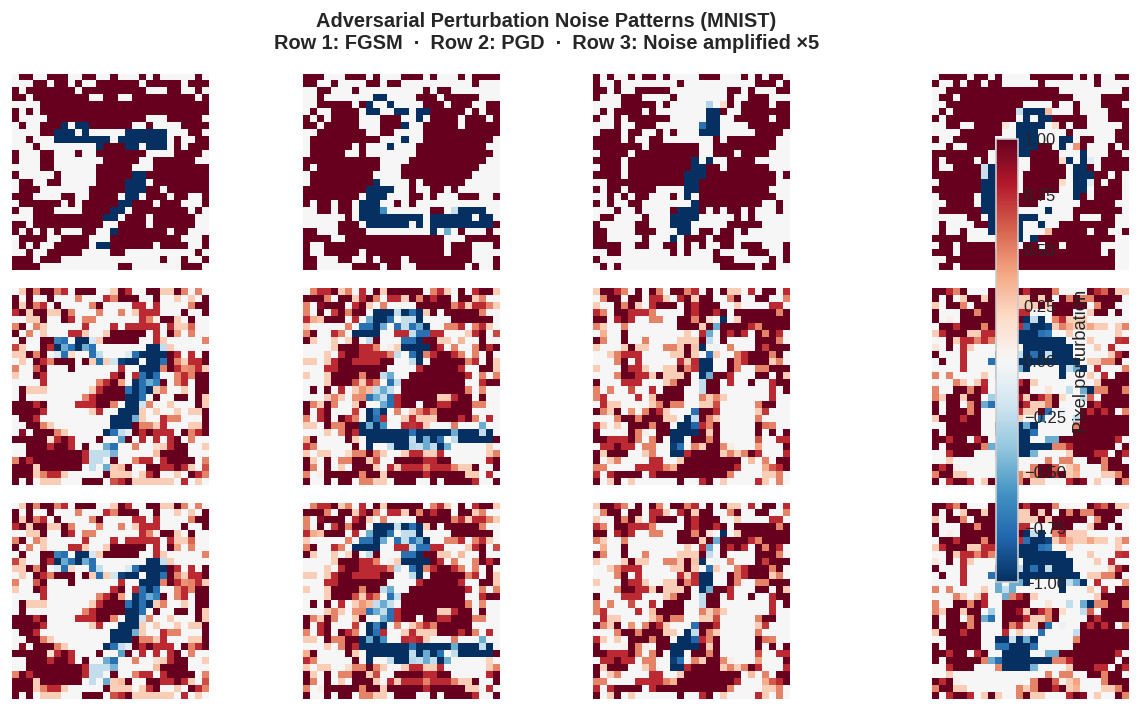

Fig 11 saved.


In [85]:
# ── Figure 11: Visualise perturbation noise patterns ──────────────────────────
# Shows the actual delta (adv - clean) to illustrate attack structure

N_SHOW_N = 4

fig, axes = plt.subplots(3, N_SHOW_N, figsize=(10, 6))
fig.suptitle('Adversarial Perturbation Noise Patterns (MNIST)\n'
             'Row 1: FGSM  ·  Row 2: PGD  ·  Row 3: Noise amplified ×5',
             fontsize=12, fontweight='bold')

fgsm_delta = (adv_fgsm_sr[:N_SHOW_N] - imgs_v[:N_SHOW_N]).cpu()
pgd_delta  = (adv_pgd_sr[:N_SHOW_N]  - imgs_v[:N_SHOW_N]).cpu()

for col in range(N_SHOW_N):
    for row, (delta, lbl) in enumerate([
        (fgsm_delta, 'FGSM δ'),
        (pgd_delta,  'PGD δ'),
        (pgd_delta * 5, 'PGD δ ×5'),
    ]):
        ax = axes[row, col]
        d_np = delta[col].squeeze().numpy()
        # Use diverging colormap centred at 0
        vmax = np.abs(d_np).max() + 1e-6
        im = ax.imshow(d_np, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(lbl, fontsize=9, fontweight='bold', rotation=90, labelpad=4)

plt.colorbar(im, ax=axes[:, -1], shrink=0.8, label='Pixel perturbation')
plt.tight_layout()
plt.savefig('figures/fig11_perturbation_noise.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 11 saved.')

## 15 · Figure 12 — Spike Activity Under Attack

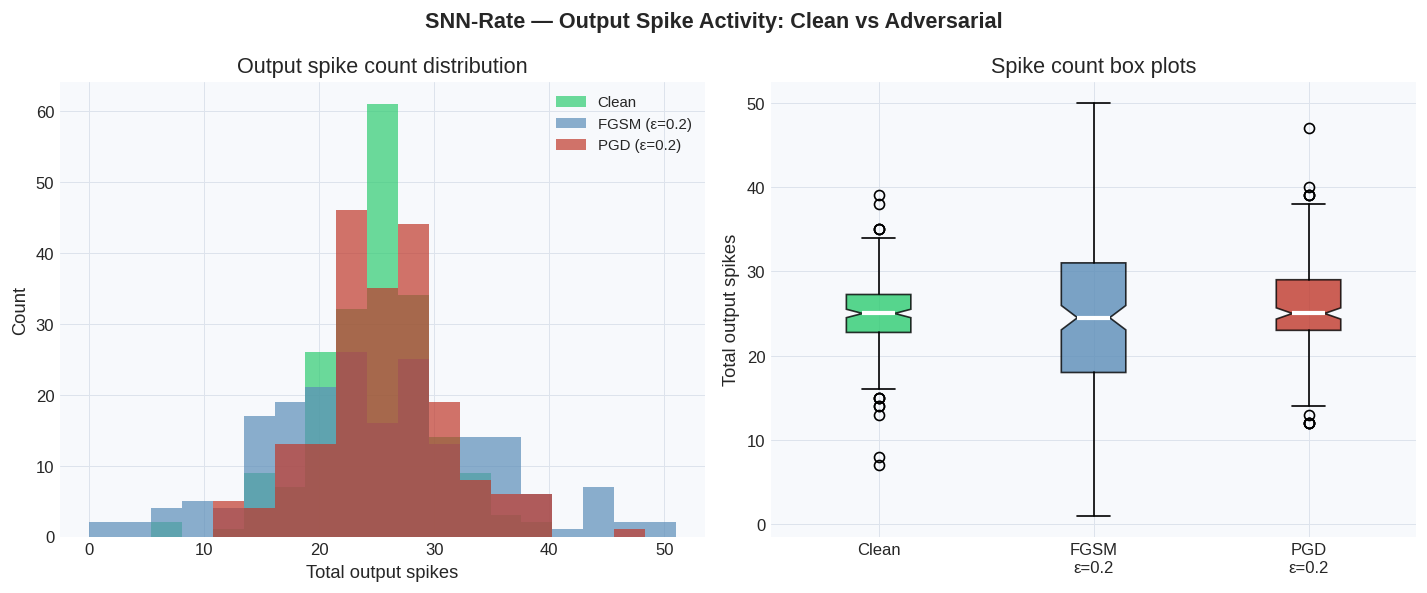

Fig 12 saved.


In [79]:
# ── Figure 12: Compare spike counts — clean vs adversarial ────────────────────
# Shows how many spikes fire at the output layer for correct vs attacked inputs

def get_spike_counts(model, imgs, encode_fn, num_steps):
    """Returns the output spike count vector for each sample."""
    model.eval()
    with torch.no_grad():
        spikes = encode_fn(imgs, num_steps).to(imgs.device)
        # We need layer-wise; get output sum
        out = model(spikes)  # shape (B, 10)
    return out.cpu().numpy()

n_sample = 200
sample_loader = DataLoader(torch.utils.data.Subset(mnist_test, range(n_sample)),
                            batch_size=n_sample, num_workers=0)
imgs_s, labels_s = next(iter(sample_loader))
imgs_s, labels_s = imgs_s.to(device), labels_s.to(device)

adv_fgsm_s = fgsm_attack_snn(model_sr, imgs_s, labels_s, EPS_VIZ_M, SNN_STEPS, 'rate')
adv_pgd_s  = pgd_attack_snn(model_sr, imgs_s, labels_s, EPS_VIZ_M, 10, None, SNN_STEPS, 'rate')

sc_clean = get_spike_counts(model_sr, imgs_s, rate_encode, SNN_STEPS)
sc_fgsm  = get_spike_counts(model_sr, adv_fgsm_s, rate_encode, SNN_STEPS)
sc_pgd   = get_spike_counts(model_sr, adv_pgd_s,  rate_encode, SNN_STEPS)

# Total output spikes (sum over all output neurons)
total_clean = sc_clean.sum(axis=1)
total_fgsm  = sc_fgsm.sum(axis=1)
total_pgd   = sc_pgd.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('SNN-Rate — Output Spike Activity: Clean vs Adversarial',
             fontsize=13, fontweight='bold')

# Histogram
ax = axes[0]
bins = np.linspace(0, max(total_clean.max(), total_fgsm.max(), total_pgd.max()) + 1, 20)
ax.hist(total_clean, bins=bins, alpha=0.7, color=PALETTE['clean'],       label='Clean')
ax.hist(total_fgsm,  bins=bins, alpha=0.7, color=PALETTE['snn_rate'],    label=f'FGSM (ε={EPS_VIZ_M})')
ax.hist(total_pgd,   bins=bins, alpha=0.7, color=PALETTE['pgd'],         label=f'PGD (ε={EPS_VIZ_M})')
ax.set_xlabel('Total output spikes'); ax.set_ylabel('Count')
ax.set_title('Output spike count distribution')
ax.legend()

# Box plot
ax = axes[1]
bp_data = [total_clean, total_fgsm, total_pgd]
bp_colors = [PALETTE['clean'], PALETTE['snn_rate'], PALETTE['pgd']]
bp = ax.boxplot(bp_data, patch_artist=True, notch=True,
                medianprops={'color': 'white', 'linewidth': 2.5})
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_xticklabels(['Clean', f'FGSM\nε={EPS_VIZ_M}', f'PGD\nε={EPS_VIZ_M}'])
ax.set_ylabel('Total output spikes')
ax.set_title('Spike count box plots')

plt.tight_layout()
plt.savefig('figures/fig12_spike_activity.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 12 saved.')

## 16 · Figure 13 — Confidence Distribution Under Attack

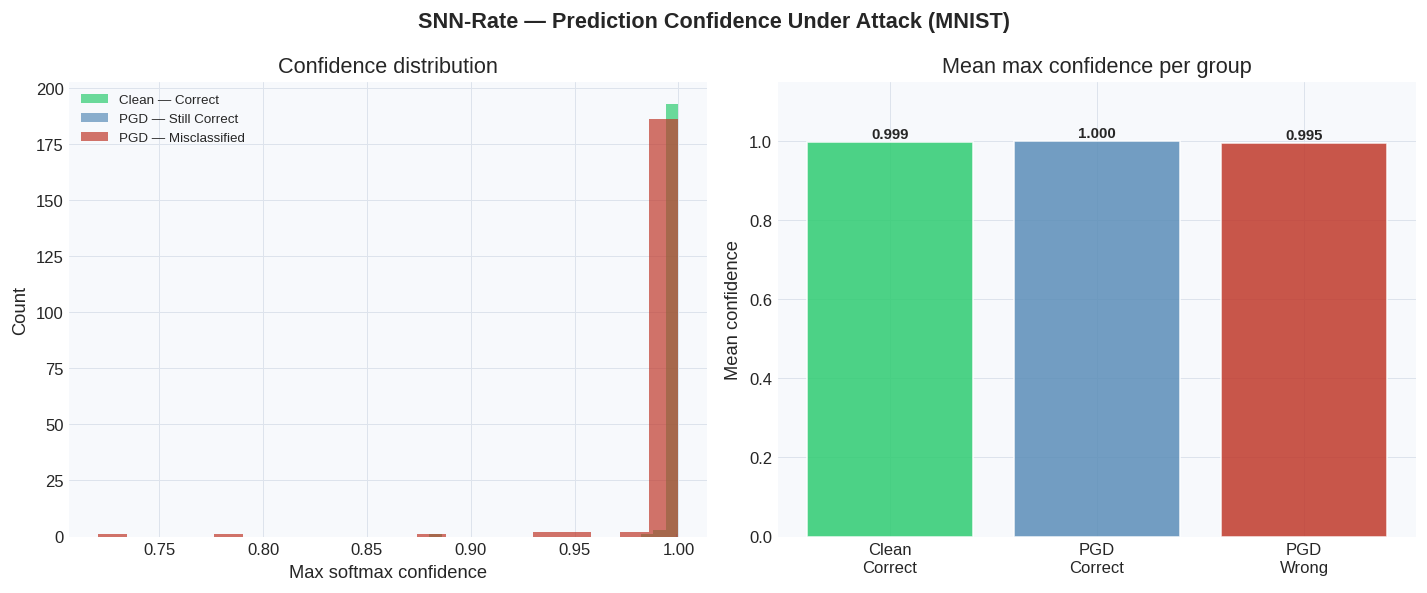

Fig 13 saved.


In [80]:
# ── Figure 13: Softmax confidence — correct vs misclassified under PGD ────────

def get_softmax_conf(model, imgs, encode_fn, num_steps, is_snn=True):
    model.eval()
    with torch.no_grad():
        if is_snn:
            spikes = encode_fn(imgs, num_steps).to(imgs.device)
            logits = model(spikes)
        else:
            logits = model(imgs)
        probs = torch.softmax(logits.float(), dim=1)
        max_conf, preds = probs.max(dim=1)
    return max_conf.cpu().numpy(), preds.cpu().numpy()

imgs_s, labels_s = imgs_s.to(device), labels_s.to(device)

conf_clean_sr, pred_c_sr = get_softmax_conf(model_sr, imgs_s, rate_encode, SNN_STEPS, True)
conf_pgd_sr,   pred_p_sr = get_softmax_conf(model_sr, adv_pgd_s, rate_encode, SNN_STEPS, True)

correct_mask_clean = (pred_c_sr == labels_s.cpu().numpy())
correct_mask_pgd   = (pred_p_sr == labels_s.cpu().numpy())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('SNN-Rate — Prediction Confidence Under Attack (MNIST)',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(conf_clean_sr[correct_mask_clean],  bins=20, alpha=0.7, color=PALETTE['clean'],
        label='Clean — Correct')
ax.hist(conf_pgd_sr[correct_mask_pgd],      bins=20, alpha=0.7, color=PALETTE['snn_rate'],
        label='PGD — Still Correct')
ax.hist(conf_pgd_sr[~correct_mask_pgd],     bins=20, alpha=0.7, color=PALETTE['pgd'],
        label='PGD — Misclassified')
ax.set_xlabel('Max softmax confidence'); ax.set_ylabel('Count')
ax.set_title('Confidence distribution'); ax.legend(fontsize=8)

ax = axes[1]
categories = ['Clean\nCorrect', 'PGD\nCorrect', 'PGD\nWrong']
means = [conf_clean_sr[correct_mask_clean].mean(),
         conf_pgd_sr[correct_mask_pgd].mean() if correct_mask_pgd.any() else 0,
         conf_pgd_sr[~correct_mask_pgd].mean() if (~correct_mask_pgd).any() else 0]
colors = [PALETTE['clean'], PALETTE['snn_rate'], PALETTE['pgd']]
bars = ax.bar(categories, means, color=colors, alpha=0.85, edgecolor='white', linewidth=1)
for bar, v in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Mean confidence')
ax.set_title('Mean max confidence per group')
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig('figures/fig13_confidence_dist.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 13 saved.')

## 17 · Final Summary

In [81]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY TABLE — print clean numbers for the paper
# ══════════════════════════════════════════════════════════════════════════════

print('=' * 72)
print('MNIST RESULTS')
print('-' * 72)
print(f'{"Model":<24} {"Clean":>8} {f"FGSM ε={EPS_M_TABLE}":>12} {f"PGD ε={EPS_M_TABLE}":>12}')
print('-' * 72)
idx_m_t = EPS_MNIST.index(EPS_M_TABLE)
for key, name in [('snn_rate','SNN — Rate Coding'), ('snn_temporal','SNN — Temporal'), ('ann','ANN (baseline)')]:
    print(f'{name:<24} {res_m[key]["fgsm"][0]:>7.1f}% {res_m[key]["fgsm"][idx_m_t]:>11.1f}% {res_m[key]["pgd"][idx_m_t]:>11.1f}%')

print()
print('=' * 72)
print('CIFAR-10 RESULTS')
print('-' * 72)
print(f'{"Model":<24} {"Clean":>8} {f"FGSM ε={EPS_C_TABLE}":>12} {f"PGD ε={EPS_C_TABLE}":>12}')
print('-' * 72)
idx_c_t = EPS_CIFAR.index(EPS_C_TABLE)
for key, name in [('snn_rate','SNN — Rate Coding'), ('snn_temporal','SNN — Temporal'), ('cnn','CNN (baseline)')]:
    print(f'{name:<24} {res_c[key]["fgsm"][0]:>7.1f}% {res_c[key]["fgsm"][idx_c_t]:>11.1f}% {res_c[key]["pgd"][idx_c_t]:>11.1f}%')

print()
print('All figures saved to ./figures/')
import os
figs = sorted(os.listdir('figures'))
for f in figs:
    print(f'  {f}')

MNIST RESULTS
------------------------------------------------------------------------
Model                       Clean   FGSM ε=0.2    PGD ε=0.2
------------------------------------------------------------------------
SNN — Rate Coding           97.9%        23.8%         3.3%
SNN — Temporal              97.8%        60.4%        37.8%
ANN (baseline)              98.4%         4.4%         0.0%

CIFAR-10 RESULTS
------------------------------------------------------------------------
Model                       Clean  FGSM ε=0.05   PGD ε=0.05
------------------------------------------------------------------------
SNN — Rate Coding           69.6%        33.4%        15.7%
SNN — Temporal              79.3%        43.4%        28.8%
CNN (baseline)              89.5%        24.0%         8.5%

All figures saved to ./figures/
  fig01_encoding_comparison.png
  fig02_mnist_learning_curves.png
  fig02b_mnist_train_vs_test.png
  fig03_cifar_learning_curves.png
  fig03b_cifar_train_vs_test.p

In [82]:
!zip -r all_outputs.zip /kaggle/working

updating: kaggle/working/ (stored 0%)
updating: kaggle/working/snn_temporal_mnist.pt (deflated 7%)
updating: kaggle/working/snn_rate_mnist.pt (deflated 7%)
updating: kaggle/working/data/ (stored 0%)
updating: kaggle/working/data/cifar-10-python.tar.gz (deflated 0%)
updating: kaggle/working/data/MNIST/ (stored 0%)
updating: kaggle/working/data/MNIST/raw/ (stored 0%)
updating: kaggle/working/data/MNIST/raw/t10k-labels-idx1-ubyte (deflated 55%)
updating: kaggle/working/data/MNIST/raw/train-images-idx3-ubyte.gz (deflated 0%)
updating: kaggle/working/data/MNIST/raw/train-images-idx3-ubyte (deflated 79%)
updating: kaggle/working/data/MNIST/raw/t10k-images-idx3-ubyte (deflated 79%)
updating: kaggle/working/data/MNIST/raw/train-labels-idx1-ubyte.gz (stored 0%)
updating: kaggle/working/data/MNIST/raw/t10k-images-idx3-ubyte.gz (deflated 0%)
updating: kaggle/working/data/MNIST/raw/t10k-labels-idx1-ubyte.gz (stored 0%)
updating: kaggle/working/data/MNIST/raw/train-labels-idx1-ubyte (deflated 52%)
